Báo cáo Phân tích Khám phá **EDA** – Dự đoán Customer Churn
---
**Mô tả dự án:**  
- Dự án thực hiện Phân tích Khám phá Dữ liệu *EDA* chuyên sâu cho bài toán dự báo tỷ lệ rời bỏ dịch vụ của khách hàng **Customer Churn**, dựa trên bộ dữ liệu tổng hợp từ *Kaggle Playground Series*, là chuỗi các cuộc thi Machine Learning hàng tháng do Kaggle tổ chức, với vai trò như một *Playground* để cộng đồng cọ xát và mài dũa kỹ năng.

**Mục tiêu chính:**  
- Kiểm tra chất lượng dữ liệu: Rà soát dữ liệu khuyết thiếu, dữ liệu trùng lặp và cấu trúc của tập dữ liệu gốc.
- Đánh giá mức độ mất cân bằng: Phân tích tỷ lệ của biến mục tiêu **Churn** để có phương án chia tập huấn luyện/kiểm thử hợp lý.
- Khám phá các đặc trưng: Dùng biểu đồ và ma trận tương quan để tìm ra những yếu tố có ảnh hưởng lớn nhất đến quyết định rời đi của khách hàng.
- So sánh tập Train và Test: Đối chiếu phân phối giữa hai tập dữ liệu nhằm đảm bảo tính đồng nhất, tránh hiện tượng trôi dạt dữ liệu **Data Drift** khi chạy mô hình.

**Định hướng kết quả:**  
- Cung cấp các kết luận phân tích cụ thể để định hình chiến lược tiền xử lý dữ liệu **Data Preprocessing**, thiết kế đặc trưng **Feature Engineering** và xây dựng mô hình học máy **Machine Learing** đạt hiệu quả tối ưu nhất.

---

 Các thành viên nhóm 14
---
| Tên          | Mã số sinh viên    |
|----------------|--------------|
| Nguyễn Lan Anh       | 24280006      |
| Lê Văn Đức (Trưởng nhóm) | 24280010|
| Trần Quang Huy| 24280015|
| Phạm Tiến Phát    | 24280018 | 
|    Hoàng Gia Bảo | 24280049      |
| Đặng Hoàng Khang| 24280076|
| Nguyễn Tiến Phát | 24280093|

# 0. Setup môi trường làm việc (Environment Setup)

## 0.1 Import thư viện (Library Imports)

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import matplotlib.ticker as mtick
import scipy.stats as ss

In [40]:
from IPython.display import display
from scipy.stats import chi2_contingency
from itertools import combinations

## 0.2 Cấu hình hiển thị và đồ thị (Display & Styling Configuration)

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid")

## 0.3 Tải dữ liệu cần thiết (Data Loading)

In [42]:
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.competition_download("playground-series-s6e3")

df_train = pd.read_csv(os.path.join(path, 'train.csv'))

print("Tải dữ liệu thành công!")
file_summary = pd.DataFrame({
    "Stt": [1],
    "File": ["train.csv"],
    "Số hàng": [len(df_train)],
    "Số cột": [df_train.shape[1]],
})
print("Mô tả kích thước dữ liệu:")
display(file_summary.set_index("Stt").rename_axis(None))

Đang tải dữ liệu từ Kaggle...
Tải dữ liệu thành công!
Mô tả kích thước dữ liệu:


,File,Số hàng,Số cột
1,train.csv,594194,21


**Note:** Thực hiện clone `df_train` và làm việc trên dữ liệu mới `df_train_copy` nhằm giữ nguyên tính toàn vẹn của dữ liệu gốc.

In [43]:
df_train_copy = df_train.copy()

# 1. Tiền xử lí dữ liệu (Data Preprocessing)

**Thông qua các bước sau để thực hiện làm sạch và chuẩn hóa dữ liệu:** 
1. Kiểm tra tổng quan dữ liệu **Overview** 
2. Kiểm tra dữ liệu rỗng **Completeness Check**
3. Kiểm tra tính trùng lặp **Validity & Consistency Check**


In [58]:
print("1. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):")
df_train_copy.info()

1. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  object 
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-nul

In [ ]:
print("2. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):")
if df_train_copy.isnull().sum().sum() == 0:
    print("Không có dữ liệu rỗng trong tập dữ liệu training.csv.")
else:
    print("Tồn tại dữ liệu rỗng trong tập dữ liệu training.csv, cụ thể phân bố dữ liệu rỗng:")
    print(df_train_copy.isnull().sum())
print("\n3. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):")
if df_train_copy.duplicated().sum() == 0:
    print("Không có dữ liệu trùng lặp trong tập dữ liệu.")
else:
    print("Tồn tại", df_train_copy.duplicated().sum(), "hàng dữ liệu trùng lặp trong tập dữ liệu.")

2. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):
Không có dữ liệu rỗng trong tập dữ liệu training.csv.

3. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):
Không có dữ liệu trùng lặp trong tập dữ liệu.


# 2. Khảo sát dữ liệu tổng quan (Dataset Overview)

## 2.1 Mô tả sơ bộ (Preliminary Overview)

| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id` | int64 | Mã định danh của khách hàng |
| `gender` | object | Giới tính |
| `SeniorCitizen` | int64 | Khách hàng có là người cao tuổi (>= 65 tuổi)? ($1$: Có, $0$: Không)|
| `Partner` | object | Khách hàng có sống chung với vợ/chồng?|
| `Dependents` | object | Khách hàng có cần được chăm sóc?|
| `tenure` | int64 | `Thời gian sử dụng dịch vụ`: Thời gian khách hàng đã gắn bó và sử dụng dịch vụ, tính theo tháng|
| `PhoneService` | object | Khách hàng có đăng ký dịch vụ điện thoại?|
| `MultipleLines` | object | Khách hàng có sử dụng nhiều đường dây điện thoại cùng lúc?|
| `InternetService` | object | Loại dịch vụ Internet mà khách hàng đang dùng|
| `OnlineSecurity` | object | Khách hàng có đăng ký gói bảo mật mạng trực tuyến?|
| `OnlineBackup` | object | Khách hàng có đăng ký gói sao lưu dữ liệu đám mây?|
| `DeviceProtection` | object | Khách hàng có mua gói bảo vệ thiết bị?|
| `TechSupport` | object | Khách hàng có đăng ký dịch vụ hỗ trợ kỹ thuật?|
| `StreamingTV` | object | Khách hàng có sử dụng Internet để xem truyền hình?|
| `StreamingMovies` | object | Khách hàng có sử dụng Internet để xem phim trực tuyến?|
| `Contract`| object | Loại hợp đồng thanh toán khách hàng đã ký?|
| `PaperlessBilling` | object | Khách hàng có nhận hóa đơn điện tử?|
| `PaymentMethod` | object | Phương thức thanh toán|
| `MonthlyCharges` | float64 | `Cước phí theo tháng`, ghi nhận vào tháng cuối cùng khảo sát được|
| `TotalCharges` | float64 | `Tổng cước phí`, ghi nhận trong suốt quá trình khảo sát|
| `Churn` | object | `Biến mục tiêu (Target)`: Đến thời điểm kết thúc khảo sát, khách hàng có rời bỏ dịch vụ không?|

**Note:** Đưa biến `SeniorCitizen` về hai giá trị *Yes/No* thay cho $1/0$ như trong dữ liệu gốc để đồng nhất so với các biến nhị phân khác. Khi thực hiện **Machine Learning** ta trả giá trị các biến nhị phân về giá trị nhị phân tương ứng của chúng.

In [45]:
df_train_copy['SeniorCitizen'] = df_train_copy['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

## 2.2 Phân nhóm và Xác định vai trò của biến (Feature Role & Type Classification)
Thực hiện phân nhóm các biến theo vai trò của chúng, cụ thể là các nhóm:
- *Biến định danh* **Identifiers**
- *Biến định lượng* **Numerical Features**
- *Biến định tính* **Categorical Features**
- *Biến mục tiêu* **Target**: Là mục tiêu của dự án này, biến `Churn`


**Note:** *Biến định danh* như tên gọi, định danh một đối tượng, không mang ý nghĩa về thống kê nhưng rất có ích trong quá trình kiểm tra các dữ liệu trống và dữ liệu lỗi giai đoạn tiền xử lí dữ liệu. 

In [46]:
identifier_data= df_train_copy['id']
identifier_features = [identifier_data.name]

print(f'Có {len(identifier_features)} biến định danh:', end=" ")
print(identifier_features)


Có 1 biến định danh: ['id']


**Note:** Biến định lượng biểu diễn các giá trị đo lường bằng số cụ thể, mang ý nghĩa thống kê rõ rệt. Nhóm biến này giúp ta xác định được các chỉ số mô tả quan trọng như giá trị trung bình, độ phân tán và hình dáng phân phối của dữ liệu trước khi đi sâu vào phân tích.

In [47]:
numerical_data = df_train_copy.select_dtypes(include='number').drop('id', axis=1, errors='ignore')
numerical_features = numerical_data.columns.tolist()

print(f'Có {len(numerical_features)} biến định lượng:', end=" ")
print(numerical_features)

Có 3 biến định lượng: ['tenure', 'MonthlyCharges', 'TotalCharges']


**Note:** Biến định tính dùng để phân loại dữ liệu dựa trên các đặc tính hoặc danh mục cụ thể. Việc gom nhóm biến này giúp ta trực quan hóa được tỉ lệ phân bố, cấu trúc của tập dữ liệu và so sánh sự khác biệt giữa các nhóm khách hàng một cách trực quan.

In [48]:
categorical_data=df_train_copy.select_dtypes(include=['object','str']).drop('Churn', axis=1, errors='ignore')
categorical_features=categorical_data.columns.tolist()

print(f'Có {len(categorical_features)} biến định tính', end=" ")
print(categorical_features)

Có 16 biến định tính ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Note:** Biến mục tiêu `Churn` được tách riêng trong giai đoạn đầu nhằm mô tả và trực quan hóa độc lập các nhóm đặc trưng. Sau khi định hình được bức tranh tổng quan, biến này sẽ được kết hợp với các đặc trưng còn lại để khai phá các quy luật ẩn sâu trong dữ liệu.

In [49]:
target_data = df_train_copy['Churn']        
target_features = [target_data.name]
print(f'Có {len(target_features)} biến mục tiêu', end=" ")
print(target_features)

Có 1 biến mục tiêu ['Churn']


# 3. Đánh giá chất lượng dữ liệu (Data Quality Assessment).

## 3.1 Kiểm tra tính hợp lệ của đặc trưng định lượng (Numerical Features Sanity Check)

**Note:** Mục tiêu của phần này là kiểm chứng tính hợp lệ về mặt toán học và logic nghiệp vụ của các biến định lượng, nhằm phát hiện và xử lý kịp thời các bản ghi chứa giá trị vô lý.

**Note:** Hàm được sử dụng để rà soát lỗi logic của giữa các nhóm biến định lượng:
   - Thời gian sử dụng dịch vụ **tenure**: Yêu cầu là số nguyên dương.
   - Giá cước hàng tháng **MonthlyCharges**: Yêu cầu không âm.
   - Tổng cước **TotalCharges**: Yêu cầu không âm.

In [50]:

checks = {
        "Số tháng sử dụng dịch vụ không nguyên dương": int(((df_train_copy["tenure"] <= 0) | (df_train_copy["tenure"] % 1 != 0)).sum()),
        "Giá cước hàng tháng không dương": int((df_train_copy["MonthlyCharges"] <= 0).sum()),
        "Tổng cước không dương": int((pd.to_numeric(df_train_copy["TotalCharges"], errors='coerce') <= 0).sum())
}
print(f"--- Kiểm tra biến định lượng ---")
display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

--- Kiểm tra biến định lượng ---


,Số lỗi phát hiện tương ứng
Số tháng sử dụng dịch vụ không nguyên dương,0
Giá cước hàng tháng không dương,0
Tổng cước không dương,0


**Nhận xét:**
- Kết quả đồng loạt bằng **0** chứng minh các biến định lượng trong tập dữ liệu hoàn toàn hợp lệ về mặt toán học lẫn logic nghiệp vụ, không tồn tại trường hợp thời gian gắn bó tenure bị âm, bị lẻ số thập phân, hay cước phí hàng tháng/tổng cước nhỏ hơn hoặc bằng **0**.
- Vì tính toàn vẹn của dữ liệu định lượng được đảm bảo tuyệt đối, ta không cần chạy thêm các hàm xử lý lỗi dư thừa như ép kiểu, cắt bỏ dòng lỗi hay dùng các kỹ thuật **imputation** để gán lại giá trị trước khi tiến hành phân tích phân phối.
- Việc biến `tenure` luôn là số nguyên dương kết hợp với các cột cước phí dương hoàn toàn tạo ra nền tảng toán học an toàn. Điều này giúp ta thoải mái thực hiện các phép toán cấu trúc ở bước **Feature Engineering**, chẳng hạn như tạo biến tỷ lệ `TotalCharges/tenure` để tính chi phí thực tế trung bình, mà không sợ gặp phải lỗi chia cho không **ZeroDivisionError** hoặc sinh ra các giá trị vô cực **Inf** làm hỏng mô hình.

## 3.2. Khảo sát phân phối và Kiểm soát điểm ngoại lai (Outlier Detection)

**Note:** Mục tiêu của phần này là phân tích và trực quan hóa các biến định lượng bằng đồ thị Boxplot và bằng hàm nhằm tìm kiếm, đánh giá và có phương án xử lý **capping** các giá trị ngoại lai nếu có, tránh làm nhiễu mô hình dự đoán.

**Note:** Hàm đổi tên biến, sử dụng cho mục đích hiển thị

In [64]:
column_mapping = {
    'tenure': 'thời gian sử dụng dịch vụ',
    'MonthlyCharges': 'cước phí hàng tháng',
    'TotalCharges': 'tổng cước phí'
}

def get_name(col_name):
    return column_mapping.get(col_name, col_name)

**Note:** Trực quan hóa phân bố khách hàng theo các đặc trưng định tính bằng đồ thị Boxplot

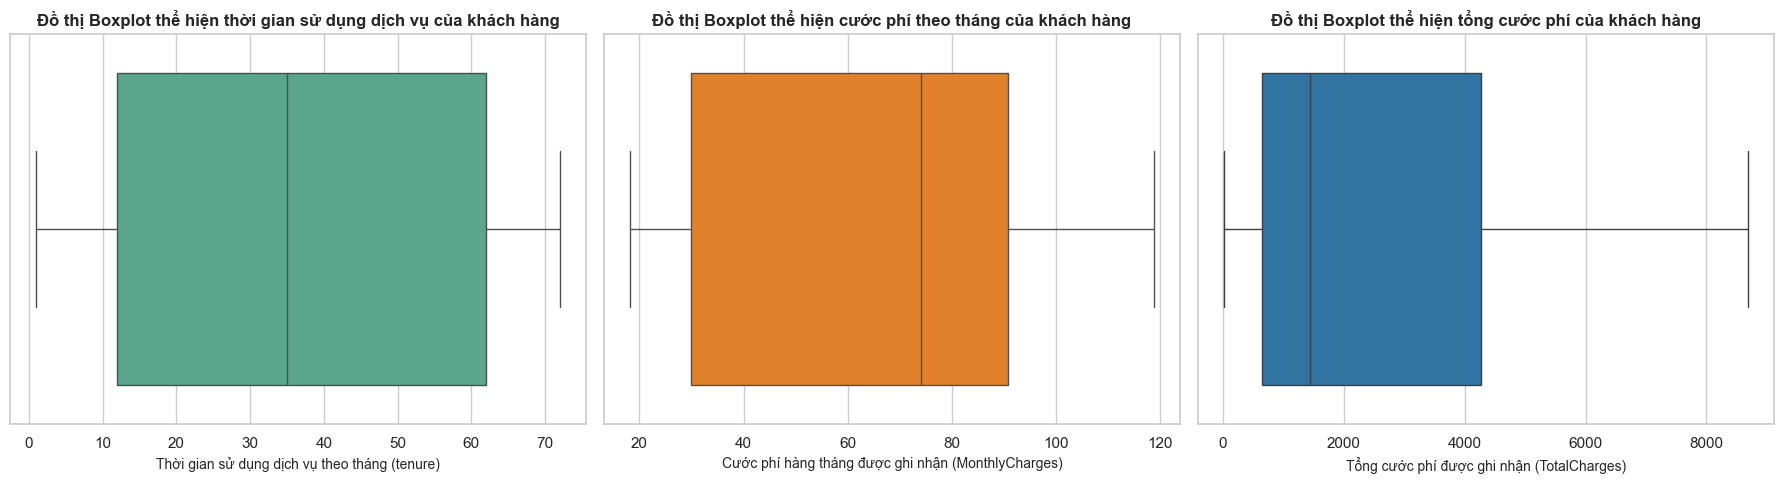

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_train_copy, x='tenure', color='#4CB391', ax=axes[0])
axes[0].set_title(f'Đồ thị Boxplot thể hiện {get_name("tenure")} của khách hàng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian sử dụng dịch vụ theo tháng (tenure)', fontsize=10)

sns.boxplot(data=df_train_copy, x='MonthlyCharges', color='#FF7F0E', ax=axes[1])
axes[1].set_title(f'Đồ thị Boxplot thể hiện {get_name("MonthlyCharges")} của khách hàng', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cước phí hàng tháng được ghi nhận (MonthlyCharges)', fontsize=10)

sns.boxplot(data=df_train_copy, x='TotalCharges', color='#1F77B4', ax=axes[2])
axes[2].set_title(f'Đồ thị Boxplot thể hiện {get_name("TotalCharges")} của khách hàng', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tổng cước phí được ghi nhận (TotalCharges)', fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét:** Bằng trực quan hóa, ta nhận thấy rằng tất cả quan sát đều nằm trong khoảng không có điểm ngoại lai **Non-outlier region** của cả ba biến định lượng `tenure`, `MonthlyCharges`, `TotalCharges`. Điều này được thể hiện rõ hơn thông qua hàm dưới đây.

**Note:** Hàm thực hiện tìm khoảng phạm vi dữ liệu hợp lệ **Valid Data Range**, sau đó đếm số điểm ngoại lai ứng với từng biến.

In [53]:
def detect_outliers_bounds(columns):
    for col in columns:
        Q1 = df_train_copy[col].quantile(0.25)
        Q3 = df_train_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = ((df_train_copy[col] < lower_bound) | (df_train_copy[col] > upper_bound)).sum()

        print(f"Số điểm ngoại lai ứng với đặc trưng {get_name(col)} ({col}): {outliers_count} điểm.\n")

**Note:** Gọi lại hàm để kiểm tra điểm ngoại lai cho cả **3** đặc trưng định lượng.

In [54]:
detect_outliers_bounds(['tenure', 'MonthlyCharges', 'TotalCharges'])

Số điểm ngoại lai ứng với đặc trưng thời gian sử dụng dịch vụ (tenure): 0 điểm.

Số điểm ngoại lai ứng với đặc trưng cước phí theo tháng (MonthlyCharges): 0 điểm.

Số điểm ngoại lai ứng với đặc trưng tổng cước phí (TotalCharges): 0 điểm.



**Nhận xét:** Qua các bước kiểm định chéo, cả ba đặc trưng định lượng `tenure`, `MonthlyCharges` và `TotalCharges` không chỉ đảm bảo tính hợp lệ tuyệt đối về mặt toán học và logic nghiệp vụ, mà còn thể hiện phân phối tự nhiên không chứa điểm ngoại lai **outliers**; do đó, mọi kỹ thuật can thiệp dữ liệu, chẳng hạn như **imputation**, **dropping** hay **capping** đều được lược bỏ để bảo toàn thông tin gốc cho mô hình.

## 3.3 Kiểm tra tính hợp lệ biến định tính (Categorical Features Sanity Check)

**Note:** Mục tiêu của phần này là rà soát tính nhất quán và logic phân lớp của các biến định tính, đặc biệt tập trung vào mối liên hệ hệ thống giữa dịch vụ cốt lõi và các dịch vụ bổ trợ, nhằm triệt tiêu hoàn toàn các mâu thuẫn dữ liệu trước khi tiến hành mã hóa *Encoding*.

**Note:** Hàm được sử dụng để rà soát lỗi logic chéo giữa các nhóm biến định tính có liên hệ mật thiết với nhau:
   - Nhóm dịch vụ Internet: Kiểm tra mâu thuẫn giữa biến `InternetService` và các dịch vụ đi kèm `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, chẳng hạn như các dịch vụ đi kèm lại hiển thị Yes trong khi trạng thái lại là No Internet.
   - Nhóm dịch vụ Điện thoại: Kiểm tra mâu thuẫn tương tự giữa `PhoneService` và `MultipleLines`.

In [55]:
internet_dependent_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
phone_dependent_cols = ["MultipleLines"]

checks = {
        "Sử dụng dịch vụ internet nhưng không có internet": int(
            df_train_copy.loc[df_train_copy["InternetService"].eq("No"), internet_dependent_cols]
            .ne("No internet service").any(axis=1).sum()
        ),
        "Sử dụng internet nhưng không có dịch vụ internet": int(
            df_train_copy.loc[~df_train_copy["InternetService"].eq("No"), internet_dependent_cols]
            .eq("No internet service").any(axis=1).sum()
        ),
        "Sử dụng dịch vụ điện thoại nhưng không có điện thoại": int(
            df_train_copy.loc[df_train_copy["PhoneService"].eq("No"), phone_dependent_cols]
            .ne("No phone service").any(axis=1).sum()
        ),
        "Sử dụng điện thoại nhưng không có dịch vụ điện thoại": int(
            df_train_copy.loc[df_train_copy["PhoneService"].eq("Yes"), phone_dependent_cols]
            .eq("No phone service").any(axis=1).sum()
        ),
    }
    
print("--- Kiểm tra biến phân loại ---")
display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

--- Kiểm tra biến phân loại ---


,Số lỗi phát hiện tương ứng
Sử dụng dịch vụ internet nhưng không có internet,0
Sử dụng internet nhưng không có dịch vụ internet,0
Sử dụng dịch vụ điện thoại nhưng không có điện thoại,0
Sử dụng điện thoại nhưng không có dịch vụ điện thoại,0


**Nhận xét:** 
-  Kết quả đồng loạt bằng $0$ chứng minh tập dữ liệu thô cực kỳ nhất quán, không bị dính các bản ghi lỗi logic. Những trường hợp vô lý như khách hàng không đăng ký Internet nhưng lại được ghi nhận là có dùng gói bảo mật mạng `OnlineSecurity` không xuất hiện.
-  Vì logic dữ liệu hoàn toàn đồng bộ, ta không cần phải viết thêm các hàm xử lý ngoại lệ hay gán lại nhãn **imputation** để sửa lỗi mâu thuẫn dịch vụ.
-  Khi thực hiện mã hóa **One-Hot Encoding** cho các biến dịch vụ bổ trợ, việc các nhóm `No internet service` hay `No phone service` có logic trùng khớp tuyệt đối với nhóm No của dịch vụ chính sẽ tạo ra các cột có độ tương quan hoàn hảo. Hệ thống hoàn toàn có thể tận dụng cấu trúc sạch này để tạo ra các biến phái sinh dạng gộp **Combo flags** mà không sợ bị lệch tín hiệu.

# 4. Phân tích Đơn biến: Khảo sát đặc trưng (Univariate Analysis)

## 4.1 Biến định lượng (Numerical Features)

**Note:** Việc thực hiện phân tích đơn biến đối với nhóm biến định lượng nhằm:

- Đánh giá hình dáng phân phối và các thông số về độ lệch, phương sai để thấu hiểu đặc tính thống kê nguyên bản của dữ liệu.
- Thông qua số lượng giá trị phân biệt và đồ thị trực quan để xác định chiến lược chuẩn hóa hoặc biến đổi dữ liệu **Data Transformation** phù hợp trước khi đưa vào huấn luyện.

**Note:** Phân tích tổng quan phân bố các biến định lượng

In [ ]:
variance = numerical_data.var()
skewness = numerical_data.skew()
unique_counts = numerical_data.nunique()

summary_table = pd.DataFrame({
    'Variance (Phương sai)': variance,
    'Skewness (Độ lệch)': skewness,
    'Nunique (Số giá trị phân biệt)': unique_counts
}).T

display(summary_table)

,tenure,MonthlyCharges,TotalCharges
Variance (Phương sai),628.0999,965.1861,5540923.8793
Skewness (Độ lệch),0.0631,-0.2895,0.9092
Nunique (Số giá trị duy nhất),72.0000,1921.0000,31910.0000


**Nhận xét:**
- Biến `tenture` chỉ thời gian sử dụng dịch vụ, tính theo tháng, là các giá trị nguyên dương nên chỉ phân bố trong khoảng nhỏ xác định.
- Biến `MonthlyCharges`, `TotalCharges` là cước phí theo tháng và tổng cước phí nên phân bố rất rộng, và là nguồn dữ liệu quý giá để tìm ra quy luật đặc trưng khi huấn luyện mô hình. 

**Note:** Trực quan hóa các biến định lượng bằng **đồ thị Histogram** để quan sát phân bố

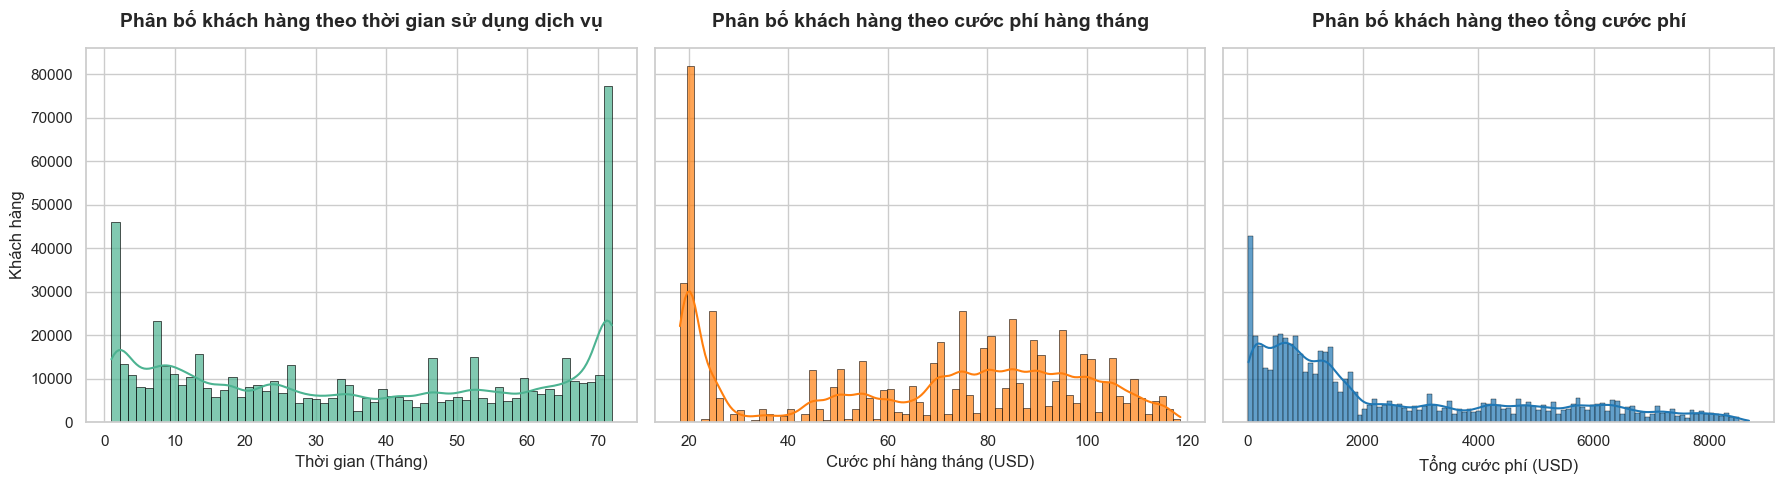

In [69]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5),sharey=True)
colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(data=df_train_copy, x=col, ax=axes[i], bins='auto', kde=True, color=colors[i], edgecolor='black', alpha=0.7,kde_kws={'cut': 0})
    
    axes[i].set_title(f'Phân bố khách hàng theo {get_name(col)}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_ylabel('Khách hàng' if i == 0 else '', fontsize=12)
axes[0].set_xlabel('Thời gian (Tháng)', fontsize=12)
axes[1].set_xlabel('Cước phí hàng tháng (USD)',fontsize=12)
axes[2].set_xlabel('Tổng cước phí (USD)',fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:**
-  Thời gian gắn bó `tenure`: Dữ liệu có dạng phân phối hai đỉnh **Bimodal Distribution**. Khách hàng tập trung với mật độ rất cao ở hai biên, gồm nhóm khách hàng mới với thời gian sử dụng dịch vụ dưới **6** tháng và nhóm khách hàng lâu năm, từ **60** tháng trở lên. Giữa hai đỉnh khách hàng phân bố tương đối đều.
- Cước phí hàng tháng `MonthlyCharges`: Dữ liệu ghi nhận một đỉnh nhọn cô lập mang giá trị rất cao ở mức phí thấp nhất, khoảng **20$**, cho thấy lượng lớn khách hàng chỉ sử dụng gói dịch vụ cơ bản nhất. Phân đoạn còn lại trải dài từ **40$** đến **115$** với các đỉnh nhỏ nhấp nhô nhưng không có mức cước nào quá áp đảo.
- Tổng cước phí `TotalCharges`: Phân phối có dạng lệch phải mạnh **Right-skewed**. Đa số khách hàng có tổng mức chi tiêu tích lũy thấp, tập trung dày đặc ở vùng sát biên trái **0$-2000$** và giảm dần với phần đuôi kéo dài đến hơn **8000$**. Điều này hoàn toàn hợp lý, bởi nhóm khách hàng mới và nhóm dùng gói cước cơ bản chiếm tỷ trọng lớn, trực tiếp kéo tổng cước phí tích lũy của họ xuống mức thấp.

**Kết luận:** 
- Dựa trên hình dạng phân phối, ta có thể chia `tenure` thành **3** nhóm  tương ứng với **3** khoảng thời gian gắn bó: *Khách hàng mới từ 1 - 6 tháng*, *Khách hàng tiêu chuẩn từ 7 - 48 tháng, và *Khách hàng lâu năm, gắn bó trên 48 tháng*. Vì các nhóm này mang ý nghĩa thứ bậc rõ ràng, phương pháp Mã hóa thứ tự **Ordinal Encoding** nên được ưu tiên để giữ lại đặc trưng này.
- Do các biến định lượng gốc có sự chênh lệch lớn về biên độ, `MonthlyCharges` ở mức hàng chục trong khi `TotalCharges` lên đến hàng nghìn, việc áp dụng các kỹ thuật chuẩn hóa như **Min-Max Scaler** hoặc **Standard Scaler** là bắt buộc nhằm tránh sai lệch trọng số cho các mô hình nhạy cảm với khoảng cách như **KNN** hay **SVM**.
- Phân bố của `TotalCharges` bị lệch phải mạnh **Right-skewed**, tuy nhiên đồ thị Boxplot cho thấy dữ liệu không xuất hiện các giá trị ngoại lai bất thường. Để xử lý dạng phân phối lệch này cho các mô hình tuyến tính như Logistic Regression, ta có thể cân nhắc giữa kỹ thuật Biến đổi Logarit **Log Transformation** hoặc thực hiện Rời rạc hóa **Binning** thành các nhóm khoảng chi tiêu nhằm làm mượt dữ liệu một cách hiệu quả.

## 4.2 Biến định tính (Categorical Features)

**Note:** Việc phân nhóm và khảo sát các biến định tính nhằm xác định không gian mẫu, từ đó xác định độ phân nhánh và cấu trúc phân bố của từng thuộc tính. Bước này giúp ta phát hiện các đặc trưng bị mất cân bằng nghiêm trọng hoặc có nhãn hiếm, làm cơ sở để xây dựng chiến lược mã hóa **Encoding** và chuẩn bị dữ liệu phù hợp cho mô hình.

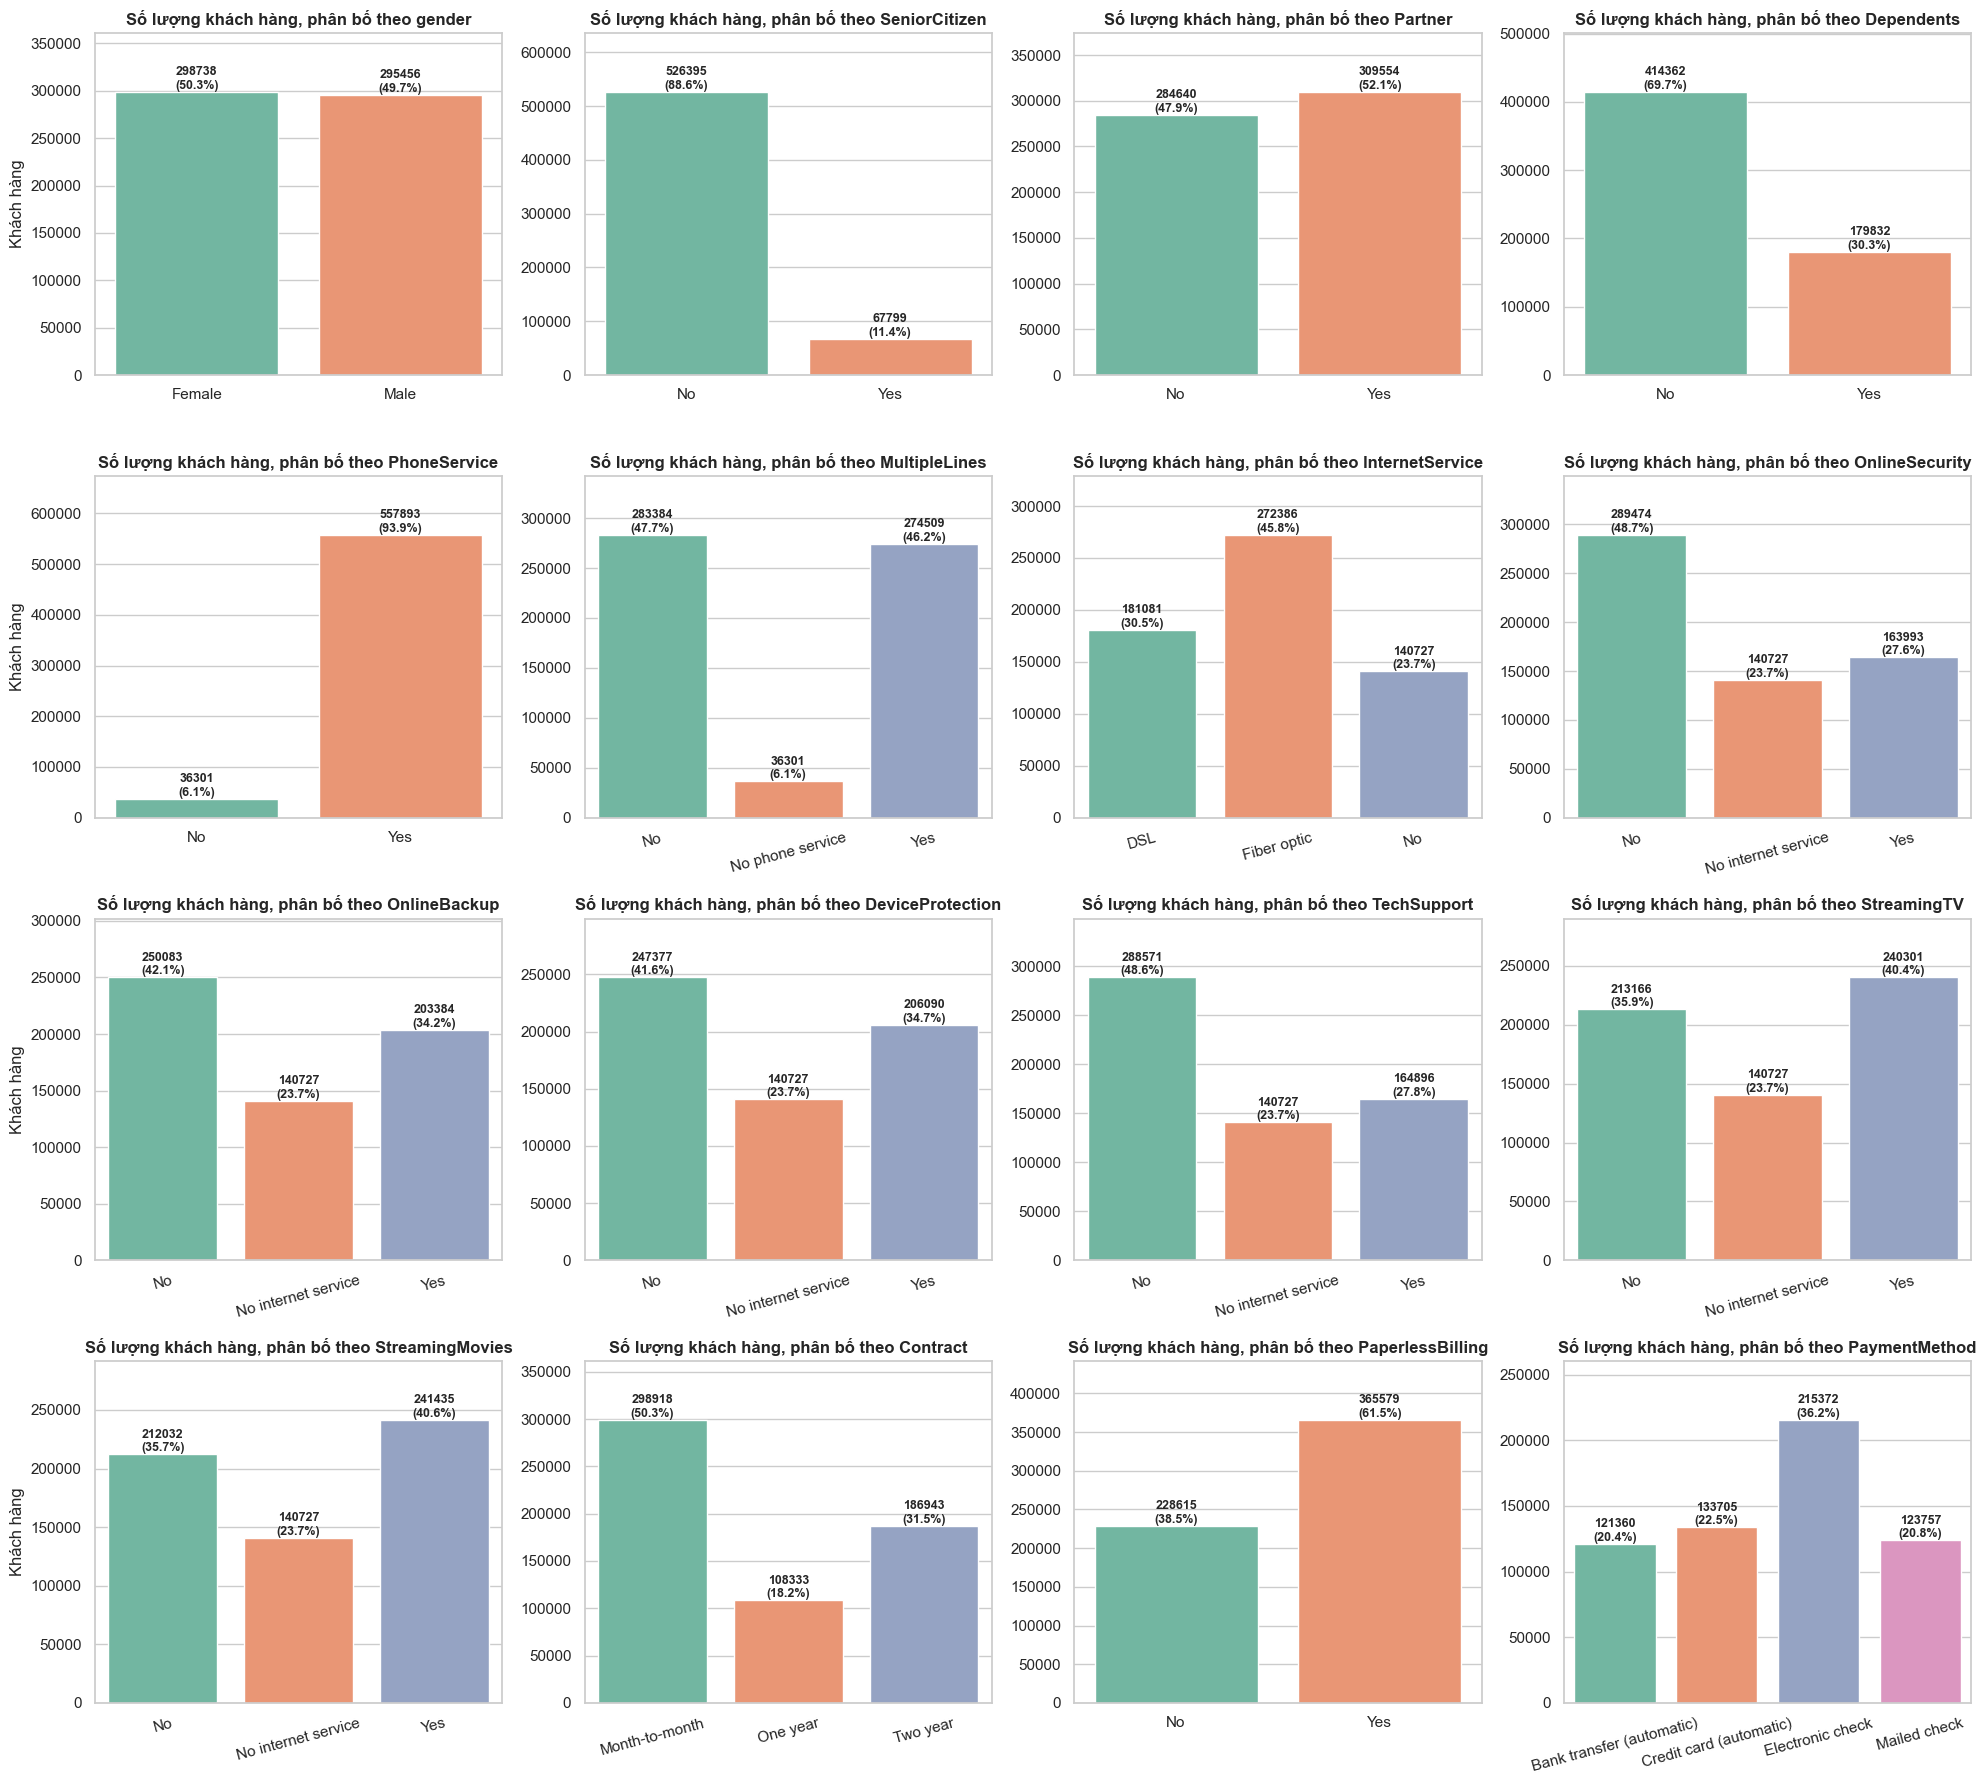

In [42]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))
axes = axes.flatten() 

for i, col in enumerate(categorical_features):
    category_order = sorted(df_train_copy[col].dropna().unique())
    
    sns.countplot(data=df_train_copy, x=col, hue=col, 
                  order=category_order, hue_order=category_order, 
                  ax=axes[i], palette='Set2', legend=False)

    total = len(df_train_copy[col].dropna())
    for p in axes[i].patches:
        count = int(p.get_height())
        pct = count / total * 100
        axes[i].annotate(
            f'{count}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )
    
    ymax = axes[i].get_ylim()[1]
    axes[i].set_ylim(0, ymax * 1.15)
    axes[i].set_title(f'Số lượng khách hàng, phân bố theo {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Khách hàng' if i % 4 == 0 else '') 
    
    if df_train_copy[col].nunique() > 2:
        axes[i].tick_params(axis='x', rotation=15)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [43]:
rows = []
for i, col in enumerate(categorical_features, start=1):
    counts = df_train_copy[col].value_counts(dropna=False)
    rows.append({
        "STT": i,
        "Tên biến (Feature)": col,
        "Số giá trị phân biệt": df_train_copy[col].nunique(dropna=False),
        "Giá trị áp đảo": counts.index[0],
        "Tỷ lệ tương ứng": counts.iloc[0] / len(df_train_copy) * 100,
        "Số giá trị hiếm (< 1%)": int((counts / len(df_train_copy) < 0.01).sum()),
    })

cat_summary = pd.DataFrame(rows)

display(cat_summary.style.format({'Tỷ lệ tương ứng': '{:.2f}%'}).hide(axis="index"))

STT,Tên biến (Feature),Số giá trị phân biệt,Giá trị áp đảo,Tỷ lệ tương ứng,Số giá trị hiếm (< 1%)
1,gender,2,Female,50.28%,0
2,SeniorCitizen,2,No,88.59%,0
3,Partner,2,Yes,52.10%,0
4,Dependents,2,No,69.74%,0
5,PhoneService,2,Yes,93.89%,0
6,MultipleLines,3,No,47.69%,0
7,InternetService,3,Fiber optic,45.84%,0
8,OnlineSecurity,3,No,48.72%,0
9,OnlineBackup,3,No,42.09%,0
10,DeviceProtection,3,No,41.63%,0


**Nhận xét:**
- Tập dữ liệu có tính phân nhánh thấp khá đồng đều. Phần lớn các biến định tính chỉ xoay quanh **2** đến **3** giá trị phân biệt, biến phức tạp nhất `PaymentMethod` cũng chỉ dừng lại ở **4** nhãn.
- Không xuất hiện tình trạng nhãn hiếm **Rare Labels**. Tất cả các nhóm giá trị trong từng biến đều chiếm tỷ trọng đáng kể với mức thấp nhất vẫn đạt trên **6.1%** như ở `PhoneService` và `MultipleLines`, không có nhóm nào rơi vào vùng nguy hiểm dưới **1%**.
- `PhoneService` có sự phân hóa thấp nhất khi nhãn *Yes* chiếm ưu thế tuyệt đối lên tới **93.89%**, theo đó lượng khách hàng không sử dụng điện thoại chỉ chiếm một phần rất nhỏ **6.1%**.
- Các nhóm biến dịch vụ gia tăng như `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` đều mang cùng một đặc điểm: Nhóm khách hàng không đăng ký internet *No internet service* luôn chiếm một tỷ lệ cố định là **23.7%**, tương đương **140,727** dòng.

**Kết luận:**
- Do toàn bộ các đặc trưng đều có độ phân nhánh thấp, phương pháp **One-Hot Encoding** sẽ được áp dụng đồng loạt để số hóa dữ liệu. Cấu trúc này đảm bảo mô hình học máy hiểu đúng các nhãn phân loại mà hoàn toàn không lo rủi ro bùng nổ chiều dữ liệu **Curse of Dimensionality**.
- Mặc dù nhóm khách hàng *No internet service* chiếm tỷ lệ cố định **23.7%** ở các biến dịch vụ đi kèm, ta quyết định giữ nguyên nhãn này thay vì gộp chung vào nhóm *No*, nhằm phục vụ cho phân tích **Risk Gap** và đo lường tỷ lệ giữ chân khách hàng nâng cao ở các bước sau, giúp làm rõ sự khác biệt về hành vi rời bỏ dịch vụ.
- Dựa trên quan sát về các biến dịch vụ đi kèm, nhãn *No internet service* hoàn toàn có thể được gộp chung vào nhãn "No" mà không làm mất mát thông tin. Việc này giúp giảm số lượng cột sau khi mã hóa **One-Hot Encoding** xuống còn một nửa đối với các biến này, giúp tập dữ liệu gọn gàng hơn.
- Vì `PhoneService` có độ phân hóa quá thấp với **93.89%** là *Yes*, đặc trưng này có nguy cơ gây nhiễu cao, cũng như mang lại ít giá trị dự báo.

### 4.3 Phân bố biến mục tiêu (Target Variable - Churn)

**Note:** Việc thực hiện phân tích sơ bộ hành vi khách hàng nhằm
1. Đánh giá tỷ lệ phân bố giữa nhóm khách hàng tiếp tục sử dụng *No* và nhóm rời bỏ dịch vụ *Yes* nhằm xác định mức độ mất cân bằng dữ liệu *Imbalanced Data*.
2. Thông qua các đánh giá để xác định chiến lược phân tách tập mẫu và lựa chọn thước đo đánh giá mô hình *Evaluation Metric* phù hợp.

**Trực quan hóa phân bố khách hàng rời bỏ dịch vụ**

In [44]:
total = len(df_train_copy)
churn_counts = df_train_copy['Churn'].value_counts().sort_index()
churn_pct = churn_counts / total * 100
labels = ['Tiếp tục sử dụng dịch vụ', 'Dừng sử dụng dịch vụ']

summary = pd.DataFrame({
    'Churn': [0, 1],
    'count': churn_counts.values,
    'pct':   churn_pct.values
})

**Note:** Đầu tiên ta bắt đầu với việc trực quan hóa phân bố khách hàng rời bỏ dịch vụ, theo biến **Churn**.

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.close(fig)

**Note:** Ta thực hiện trực quan hóa phân bố này theo hai hướng
1. Tỷ lệ khách hàng rời bỏ dịch vụ, theo biểu đồ tròn *Pie Chart*
2. Số lượng khách hàng rời bỏ dịch vụ, theo biểu đồ cột *Bar Chart*

In [46]:
churn_counts = df_train_copy['Churn'].value_counts()
pie_labels = ["Dừng sử dụng dịch vụ" if val == "Yes" else "Tiếp tục sử dụng dịch vụ" for val in churn_counts.index]

ax1.pie(churn_counts, labels=pie_labels, autopct='%1.1f%%', 
        startangle=90, colors=['#81b29a', '#e07a5f'], 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax1.set_title('Tỷ lệ khách hàng rời bỏ dịch vụ', fontsize=14, fontweight='bold');

**Note:** Biểu đồ tròn này giúp ta thấy rõ hơn sự chênh lệch tỷ lệ giữa *Nhóm khách hàng dừng sử dụng dịch vụ* và *Nhóm khách hàng tiếp tục sử dụng dịch vụ*.

In [47]:
sns.countplot(data=df_train_copy, x='Churn', hue='Churn', palette=['#81b29a', '#e07a5f'], legend=False, ax=ax2)

x_labels = [label.get_text() for label in ax2.get_xticklabels()]
bar_labels = ["Dừng sử dụng dịch vụ" if label == "Yes" else "Tiếp tục sử dụng dịch vụ" for label in x_labels]
ax2.set_xticks(ax2.get_xticks()) 
ax2.set_xticklabels(bar_labels)

ax2.set_title('Số lượng khách hàng rời bỏ dịch vụ', fontsize=14, fontweight='bold')
ax2.set_ylabel('Khách hàng')
ax2.set_xlabel('')

current_ylim = ax2.get_ylim()
ax2.set_ylim(0, current_ylim[1] * 1.15) 

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, fontweight='bold', 
                color='black', xytext=(0, 5), textcoords='offset points')

**Note:** Biểu đồ cột này giúp ta thấy rõ hơn sự chênh lệch số lượng giữa *Nhóm khách hàng dừng sử dụng dịch vụ* và *Nhóm khách hàng tiếp tục sử dụng dịch vụ*.

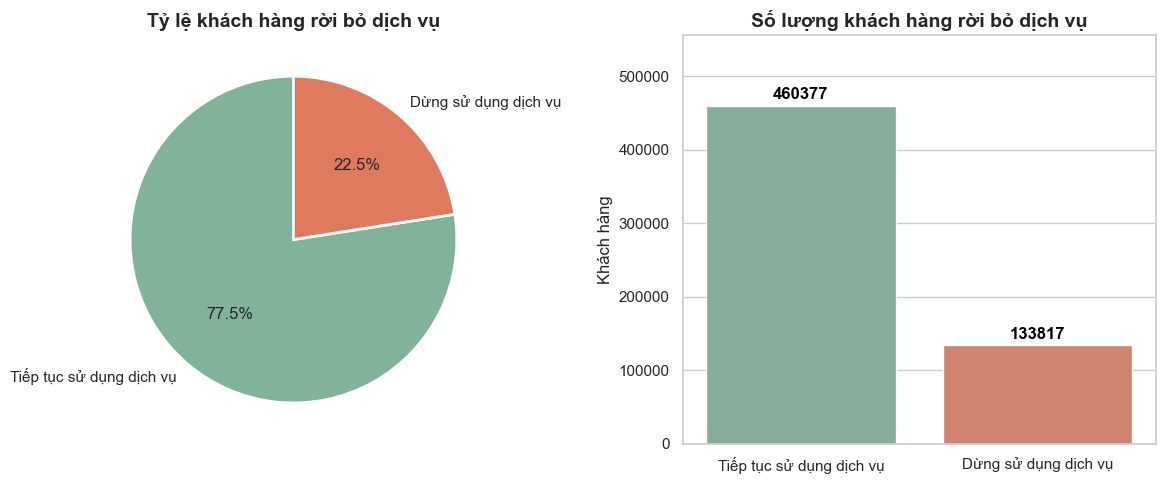

In [48]:
fig.tight_layout()
fig

**Nhận xét:** Dữ liệu thể hiện sự mất cân bằng mẫu ở mức độ vừa phải (tỷ lệ xấp xỉ $3.5 : 1$). Cụ thể:
- Nhóm khách hàng ở lại *No* chiếm đa số với $77.5\%$ ($460,377$ khách hàng)
- Nhóm khách hàng rời bỏ *Yes* - nhóm thiểu số cần dự đoán - chỉ chiếm $22.5\%$ ($133,817$ khách hàng)


**Kết luận:**
Sự mất cân bằng dữ liệu như trên đặt ra $3$ quy tắc:
* Không sử dụng *Độ chính xác tổng thể Accuracy* vì mô hình có thể đạt điểm cao một cách sai lệch khi đưa ra dự đoán tất cả là *No*. *ROC-AUC* nên được sử dụng làm thước đo chính để tối ưu hóa khả năng xếp hạng rủi ro *ranking churn risk* của mô hình.
* Yêu cầu về việc sử dụng kỹ thuật phân tầng *Stratified K-Fold* khi chia tập *Train/Validation* để đảm bảo tỷ lệ $22.5\%$ nhóm *Yes* được giữ nguyên vẹn trên mọi nếp gấp *fold*.
* Cần tập trung khai thác các biến có tính phân hóa mạnh, để giúp mô hình dễ dàng phát hiện các đặc điểm của nhóm thiểu số. Có thể cân nhắc điều chỉnh hàm mất mát như *scale_pos_weight* trong *XGBoost* để tránh hiện tượng thuật toán bị thiên lệch *bias* về phía nhóm số đông.

## 5. Phân tích Song biến: Động cơ rời bỏ (Bivariate Analysis)

**Note:** Việc thực hiện phân tích song biến *Bivariate Analysis* giữa tất cả các biến định tính, định lượng và biến mục tiêu **Churn** nhằm:
- Xác định mối liên hệ trực tiếp và đánh giá mức độ tác động của từng yếu tố cả định lượng lẫn định tính lên quyết định rời bỏ dịch vụ của khách hàng.
- Khai phá các động cơ cốt lõi *Drivers of Churn* ẩn sâu trong dữ liệu, từ đó thiết lập các giả thuyết kinh doanh *Business Hypotheses* vững chắc làm tiền đề cho phần Xây dựng và Tinh chỉnh đặc trưng *Feature Engineering* và tối ưu hóa mô hình dự đoán.

### 5.1 Phân tích nhóm biến định lượng (Numerical Features vs Target)

**Trực quan hóa các biến định lượng gốc tích hợp với thuộc tính Churn bằng đồ thị Histogram/KDE và Boxplot**

**Note:** Việc trực quan hóa phân phối của các biến định lượng gốc bằng cặp *Đồ thị phân phối (Histplot/KDE)* và *Biểu đồ hộp (Boxplot)* nhằm:

- Đánh giá hình dáng phân phối và sự dịch chuyển trọng tâm dữ liệu giữa *Nhóm khách hàng tiếp tục sử dụng Dịch vụ* và *Nhóm khách hàng dừng sử dụng dịch vụ*.
- Phát hiện các điểm gãy phân phối, các ngưỡng giá trị tới hạn và hành vi phi tuyến tính để làm cơ sở vững chắc cho các quyết định *Feature Engineering* như phân nhóm, tạo cờ cảnh báo hoặc biến đổi tỷ lệ ở bước tiếp theo.

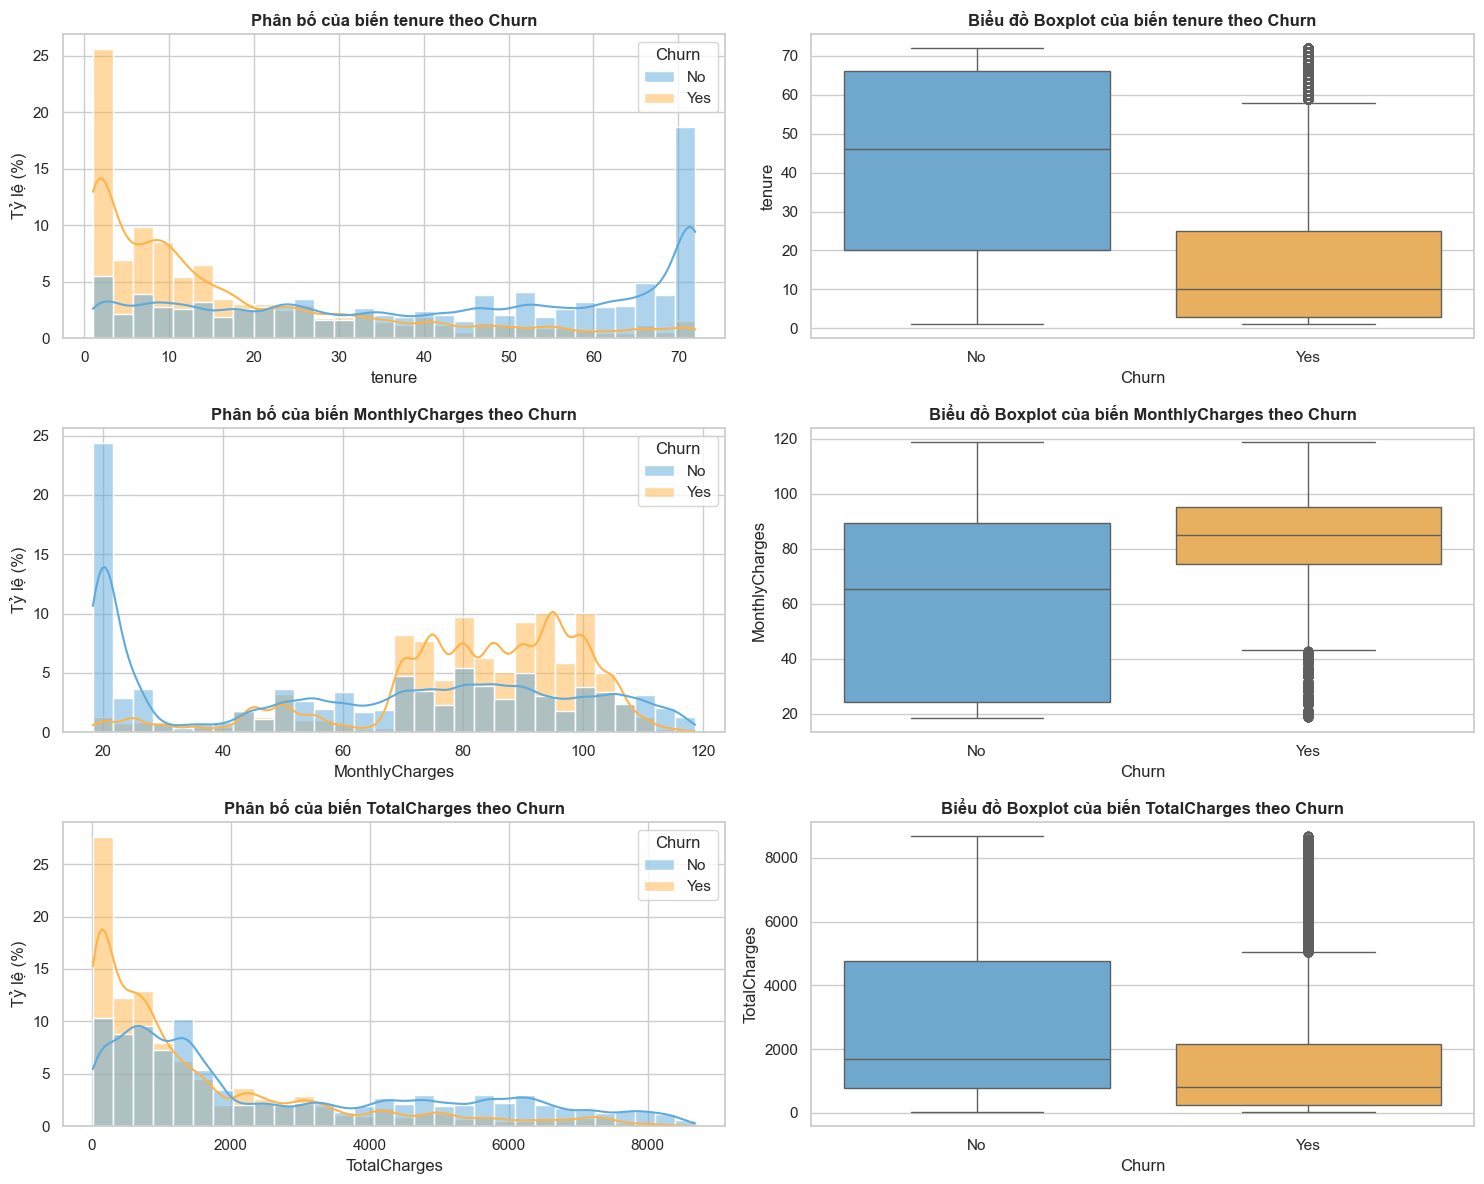

In [49]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(15, 4 * len(numerical_features)))

churn_palette = {"Yes": "#FFB347", "No": "#5FAADD"} 

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df_train_copy, 
        x=col, 
        hue="Churn", 
        kde=True, 
        bins=30,
        stat="percent", 
        common_norm=False,
        palette=churn_palette,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"Phân bố của biến {col} theo Churn", fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel("Tỷ lệ (%)")

    sns.boxplot(
        data=df_train_copy, 
        x="Churn", 
        y=col, 
        hue="Churn",
        legend=False,
        palette=churn_palette,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Biểu đồ Boxplot của biến {col} theo Churn", fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

**Nhận xét:** 
- **Thời gian gắn bó tenure**: Xuất hiện sự phân tách giữa hai nhóm. Nhóm dừng sử dụng dịch vụ có mật độ rất cao ở những tháng đầu tiên từ $1$ đến $6$ tháng và giảm dần đều. Ngược lại, nhóm tiếp tục sử dụng dịch vụ có xu hướng tập trung phần lớn tại mốc khách hàng lâu năm trên $48$ tháng. Trung vị của nhóm dừng sử dụng dịch vụ chỉ rơi vào khoảng $10$ tháng, cho thấy rủi ro dừng sử dụng dịch vụ diễn ra cực kỳ sớm.
- **Cước phí hàng tháng MonthlyCharges**: Nhóm tiếp tục sử dụng dịch vụ tạo một đỉnh rất cao ở phân khúc giá rẻ quanh mốc $20$. Trong khi đó, nhóm dừng sử dụng dịch vụ chiếm tỷ lệ áp đảo ở phân khúc cước phí cao từ $70$ đến $105$. *Boxplot* cũng chỉ ra rằng những người dừng sử dụng dịch vụ phải trả mức phí trung bình cao hơn hẳn so với nhóm tiếp tục sử dụng dịch vụ.
- **Tổng chi phí TotalCharges**: Cả hai nhóm đều có phân phối lệch phải *Right-Skewed*. Tuy nhiên, nhóm dừng sử dụng dịch vụ có mật độ rất lớn ở quanh mốc $0$. Điều này hoàn toàn hợp lí vì họ thường hủy dịch vụ ngay trong những tháng đầu, kéo theo tổng tiền chưa tích lũy được nhiều.

**Xem xét các đặc trưng định lượng mới (Numerical Feature Engineering)**

**Note:** Việc thực hiện Xây dựng và Tinh chỉnh đặc trưng đối với nhóm biến định lượng *Numerical Feature Engineering* nhằm:

- Thiết lập và khai thác các đặc trưng mới mang tính bản chất hơn về mặt nghiệp vụ như phụ phí ẩn **Extra Charges** hoặc mức độ gắn kết thông qua tổng số lượng dịch vụ sử dụng **Total Services**.
- Chuyển hóa các mối liên hệ phức tạp giữa các đặc trưng liên tục gốc thành các thuộc tính trực diện, giúp thuật toán dễ dàng nhận diện ranh giới phân loại mà không làm gia tăng quá mức độ phức tạp của mô hình.

In [50]:
df_train_copy['ExtraCharges'] = df_train_copy['TotalCharges'] - (df_train_copy['MonthlyCharges'] * df_train_copy['tenure'])

services_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df_train_copy['TotalServices'] = (df_train_copy[services_cols] == 'Yes').sum(axis=1)
new_numerical_features = ['ExtraCharges', 'TotalServices']


**Trực quan hóa các biến định lượng mới tích hợp với thuộc tính Churn bằng đồ thị Histogram/KDE và Boxplot**

**Note:** Việc tổng hợp và thống kê mô tả *Descriptive Statistics* cho các đặc trưng định lượng mới nhằm:
- Kiểm chứng tính chính xác và toàn vẹn logic của các phép biến đổi toán học vừa thực hiện, đảm bảo không xuất hiện các giá trị âm vô lý ở biến **ExtraCharges** hoặc lỗi tính toán ở biến **TotalCharges**.
- Đánh giá nhanh dải giá trị và xu hướng tập trung của các biến mới để thiết lập cấu hình trục tọa độ và tham số phù hợp nhất cho bước trực quan hóa.

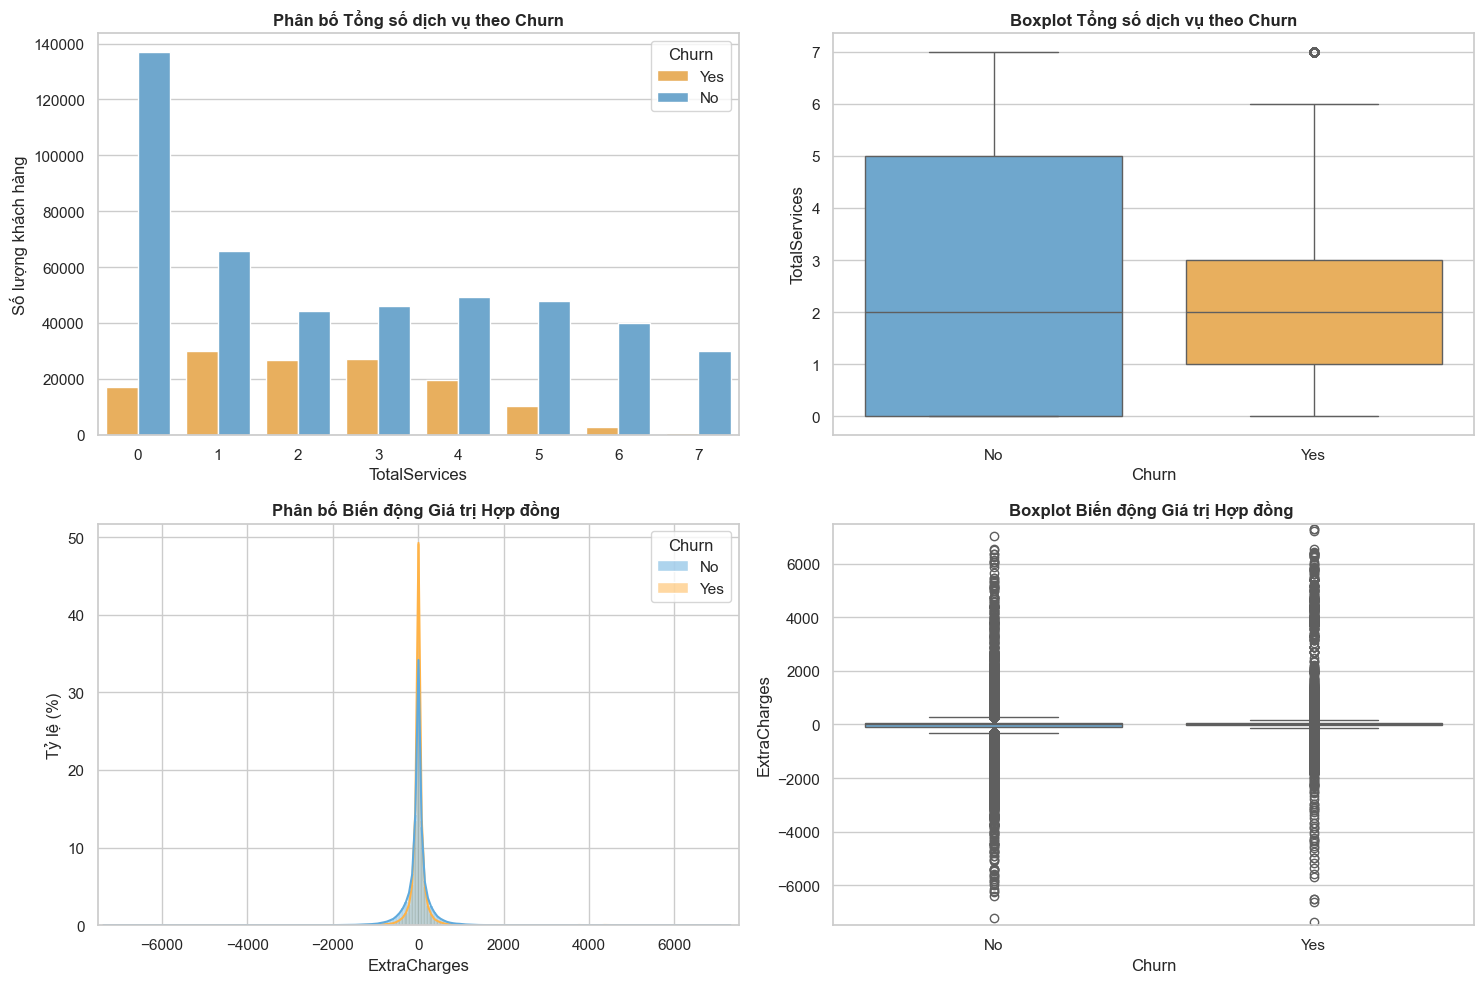

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

churn_palette = {"Yes": "#FFB347", "No": "#5FAADD"} 

sns.countplot(
    data=df_train_copy, 
    x="TotalServices", 
    hue="Churn", 
    palette=churn_palette, 
    ax=axes[0, 0]
)
axes[0, 0].set_title("Phân bố Tổng số dịch vụ theo Churn", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Số lượng khách hàng")

sns.boxplot(
    data=df_train_copy, 
    x="Churn", 
    y="TotalServices", 
    hue="Churn",
    legend=False,
    palette=churn_palette, 
    ax=axes[0, 1]
)
axes[0, 1].set_title("Boxplot Tổng số dịch vụ theo Churn", fontsize=12, fontweight='bold')

sns.histplot(
    data=df_train_copy, 
    x="ExtraCharges", 
    hue="Churn", 
    kde=True, 
    bins=200,
    stat="percent", 
    common_norm=False,
    palette=churn_palette,
    ax=axes[1, 0]
)
axes[1, 0].set_xlim(-7500, 7500)
axes[1, 0].set_title("Phân bố Biến động Giá trị Hợp đồng ", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Tỷ lệ (%)")

sns.boxplot(
    data=df_train_copy, 
    x="Churn", 
    y="ExtraCharges", 
    hue="Churn",
    legend=False,
    palette=churn_palette, 
    ax=axes[1, 1]
)
axes[1, 1].set_ylim(-7500, 7500)
axes[1, 1].set_title("Boxplot Biến động Giá trị Hợp đồng ", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Tổng số dịch vụ TotalServices:** Nhóm khách hàng dừng sử dụng dịch vụ chủ yếu chỉ dùng $1-2$ dịch vụ và giảm sâu khi số dịch vụ sử dụng tăng dần. Ngược lại, nhóm khách hàng tiếp tục sử dụng dịch vụ có phân bố tiệm cận phân bố chuẩn, với đa phần đăng kí từ $1-3$ dịch vụ
- **Biến động chi phí ẩn ExtraCharge:** Trọng tâm tuyệt đối vẫn nằm ở mốc $0$ (Tổng cước khớp với Cước tháng $\times$ Thời gian). Tuy nhiên, dải dữ liệu phân tán khá rộng về cả hai phía.


**Kết luận:**
* **Tổng số dịch vụ TotalServices:** Tỷ lệ rời bỏ dịch vụ **Churn** tập trung chủ yếu ở nhóm khách hàng chỉ dùng 1-2 dịch vụ và giảm dần ở nhóm dùng từ $4$ dịch vụ trở lên. Điều này xác nhận giả thuyết: mức độ sử dụng dịch vụ tỷ lệ nghịch với rủi ro dừng đăng ký hợp đồng.
* **Biến động chi phí ẩn ExtraCharges:** 
  - Biểu đồ bị kéo lệch bởi các giá trị ngoại lai *outliers* ở cả hai cực. Các giá trị âm sâu đại diện cho nhóm khách hàng hạ cấp gói cước hoặc được hưởng quyền lợi giảm giá, trong khi các giá trị dương lớn đại diện cho nhóm khách hàng nâng cấp gói cước hoặc phát sinh phụ phí.
  - Để tránh việc các giá trị ngoại lai khổng lồ của `ExtraCharges` làm nhiễu mô hình, cần thực hiện rời rạc hóa *Binning* biến này thành các nhóm Tăng, Ổn định, Giảm. 

### 5.2 Phân tích nhóm biến định tính (Categorical Features vs Target)

**Note:** Việc thực hiện phân tích song biến *Bivariate Analysis* đối với nhóm đặc trưng định tính *Categorical Features* và biến mục tiêu **Churn** nhằm:
- Đánh giá sự phân hóa tỷ lệ dừng sử dụng dịch vụ giữa các hạng mục khác nhau như loại hợp đồng, phương thức thanh toán,... nhằm định vị chính xác các phân khúc khách hàng mang rủi ro cao nhất.
- Khám phá các mẫu hành vi tiêu dùng dựa trên đặc tính dịch vụ, từ đó làm cơ sở khoa học để tinh chỉnh không gian mẫu *Category Grouping*, lựa chọn chiến lược mã hóa *Encoding* tối ưu.

**Phân tích mức độ phân hóa rủi ro của các biến định tính**

**Note:** Việc thiết lập bảng tính toán Mức độ phân hóa rủi ro *Risk Spread* cho nhóm biến định tính nhằm:
- Đo lường một cách định lượng khoảng cách về tỷ lệ dừng sử dụng dịch vụ *Churn Rate Gap* giữa hai nhóm thuộc tính mang rủi ro cao nhất và thấp nhất trong cùng một đặc trưng.
- Sắp xếp và sàng lọc ra những biến định tính có sức mạnh phân loại và dự đoán mạnh nhất,  định hướng trọng tâm cho các bước trực quan hóa.

In [52]:
df_train_copy = df_train_copy.assign(churn_flag=df_train_copy["Churn"].eq("Yes").astype(int))

**Note:** Gán cờ *flag* tương ứng cho biến **Churn**

In [53]:
rows = []
for col in categorical_features:
    grouped = df_train_copy.groupby(col, dropna=False)["churn_flag"].agg(churn_rate="mean", rows="size")
    grouped = grouped[grouped["rows"] >= 100]
    high = grouped.sort_values("churn_rate", ascending=False).iloc[0]
    low = grouped.sort_values("churn_rate", ascending=True).iloc[0]
    rows.append({
        "Đặc trưng":             col,
        "Số giá trị phân biệt": df_train_copy[col].nunique(),
        "Giá trị mang rủi ro cao nhất":    high.name,
        "Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro cao nhất":  high["churn_rate"] * 100,
        "Tổng số khách hàng (nhóm rủi ro cao nhất)":         int(high["rows"]),
        "Giá trị mang rủi ro thấp nhất":   low.name,
        "Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro thấp nhất": low["churn_rate"] * 100,
        "Tổng số khách hàng (nhóm rủi ro thấp nhất)":        int(low["rows"]),
        "Mức độ phân hóa rủi ro":       (high["churn_rate"] - low["churn_rate"]) * 100,
    })

risk_spread = pd.DataFrame(rows).sort_values("Mức độ phân hóa rủi ro", ascending=False)
display(risk_spread.style.format({'Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro cao nhất': '{:.2f}%', 'Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro thấp nhất': '{:.2f}%', 'Mức độ phân hóa rủi ro': '{:.2f}%'}).hide(axis="index"))

Đặc trưng,Số giá trị phân biệt,Giá trị mang rủi ro cao nhất,Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro cao nhất,Tổng số khách hàng (nhóm rủi ro cao nhất),Giá trị mang rủi ro thấp nhất,Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro thấp nhất,Tổng số khách hàng (nhóm rủi ro thấp nhất),Mức độ phân hóa rủi ro
PaymentMethod,4,Electronic check,48.91%,215372,Credit card (automatic),6.93%,133705,41.97%
Contract,3,Month-to-month,42.05%,298918,Two year,1.00%,186943,41.06%
InternetService,3,Fiber optic,41.54%,272386,No,1.43%,140727,40.11%
OnlineSecurity,3,No,40.61%,289474,No internet service,1.43%,140727,39.18%
TechSupport,3,No,40.16%,288571,No internet service,1.43%,140727,38.73%
OnlineBackup,3,No,39.10%,250083,No internet service,1.43%,140727,37.67%
DeviceProtection,3,No,38.06%,247377,No internet service,1.43%,140727,36.63%
SeniorCitizen,2,Yes,50.03%,67799,No,18.98%,526395,31.05%
StreamingMovies,3,No,29.93%,212032,No internet service,1.43%,140727,28.50%
StreamingTV,3,No,29.74%,213166,No internet service,1.43%,140727,28.31%


**Nhận xét:**
- Những đặc trưng có mức độ phân hóa lớn nhất, trên $40\%$
    * **Phương thức thanh toán PaymentMethod** có khoảng lệch lớn nhất $41.97\%$. Nhóm thanh toán bằng séc điện tử *Electronic check* có rủi ro rất cao khi tỷ lệ dừng sử dụng dịch vụ chiếm đến $48.91\%$, trong khi nhóm dùng thẻ tín dụng tự động *Credit card automatic* có rủi ro rất thấp, ở mức $6.93\%$.
    * **Loại hợp đồng Contract** theo sát **PaymentMethod** với khoảng lệch $41.06\%$. Nhóm ký hợp đồng ngắn hạn theo tháng *Month-to-month* mang rủi ro rất cao với tỷ lệ dừng sử dụng dịch vụ đạt $42.05\%$, ngược lại hợp đồng dài hạn $2$ năm *Two year* gần như triệt tiêu hoàn toàn rủi ro, chỉ $1.00\%$.
    * **Dịch vụ Internet InternetService** đứng thứ ba với khoảng lệch $40.11\%$. Đáng chú ý, nhóm sử dụng mạng cáp quang tốc độ cao *Fiber optic* lại đối mặt rủi ro dừng sử dụng dịch vụ lên đến $41.54\%$.

- Nhóm hệ sinh thái dịch vụ và yếu tố con người với mức độ phân hóa từ $20\% - 40\%$
    * Sự bảo mật kém đến từ việc không tích hợp các lớp màng bảo vệ kỹ thuật số như **OnlineSecurity**, **TechSupport**,... mang một phần nguyên nhân khiến khách hàng dừng đăng ký hợp đồng.
    * Nhóm người cao tuổi *SeniorCitizen = Yes* ghi nhận tỷ lệ dừng sử dụng dịch vụ cao nhất toàn tập dữ liệu $50.03\%$, nhưng do quy mô tập khách hàng phân khúc này khá nhỏ, biên độ phân hóa tổng thể được cân bằng lại ở mức $31.05\%$.

- Nhóm tính năng phân hóa yếu, biên độ lệch bé hơn $10\%$:
    * Thuộc tính **Giới tính gender** nằm ở cuối bảng với biên độ lệch gần như bằng không $0.57\%$, cho thấy tỷ lệ rời bỏ dịch vụ giữa Nam và Nữ đồng đều một cách tuyệt đối, xấp xỉ $22\%$. Tương tự, các dịch vụ viễn thông truyền thống như **PhoneService** hay **MultipleLines** cũng có sự phân hóa rất thấp.

**Kết luận:**
- Các đặc trưng như **PaymentMethod**, **Contract**, **InternetService** cùng cụm tính năng kỹ thuật như **OnlineSecurity**, **TechSupport** là những đặc trưng cần được chú ý vì tính phân hóa biến mục tiêu **Churn** của các đặc trưng này mang  lượng thông tin cốt lõi để phân tách **Churn**.
- Thực hiện loại bỏ hoàn toàn đặc trưng **gender** khỏi tập biến định tính cho các bước *Phân tích tương quan* và *Machine Learning*, vì lượng thông tin có ích nhận được *Information Gain* quá thấp, tránh nhiễu mô hình *Machine Learning* sau này, cũng như tiết kiệm tài nguyên.
- Yêu cầu về việc tạo thêm các *Biến chỉ báo tương tác Interaction Features*, có thể kể đến như việc kết hợp chéo giữa nhóm dùng mạng cáp quang *Fiber optic* và nhóm trả tiền theo tháng *Month-to-month* nhằm cô lập và gắn cờ cảnh báo rủi ro cho nhóm khách hàng có nguy cơ rời đi nghiêm trọng nhất.

**Trực quan hóa các biến định tính có mức phân hóa rủi ro cao**

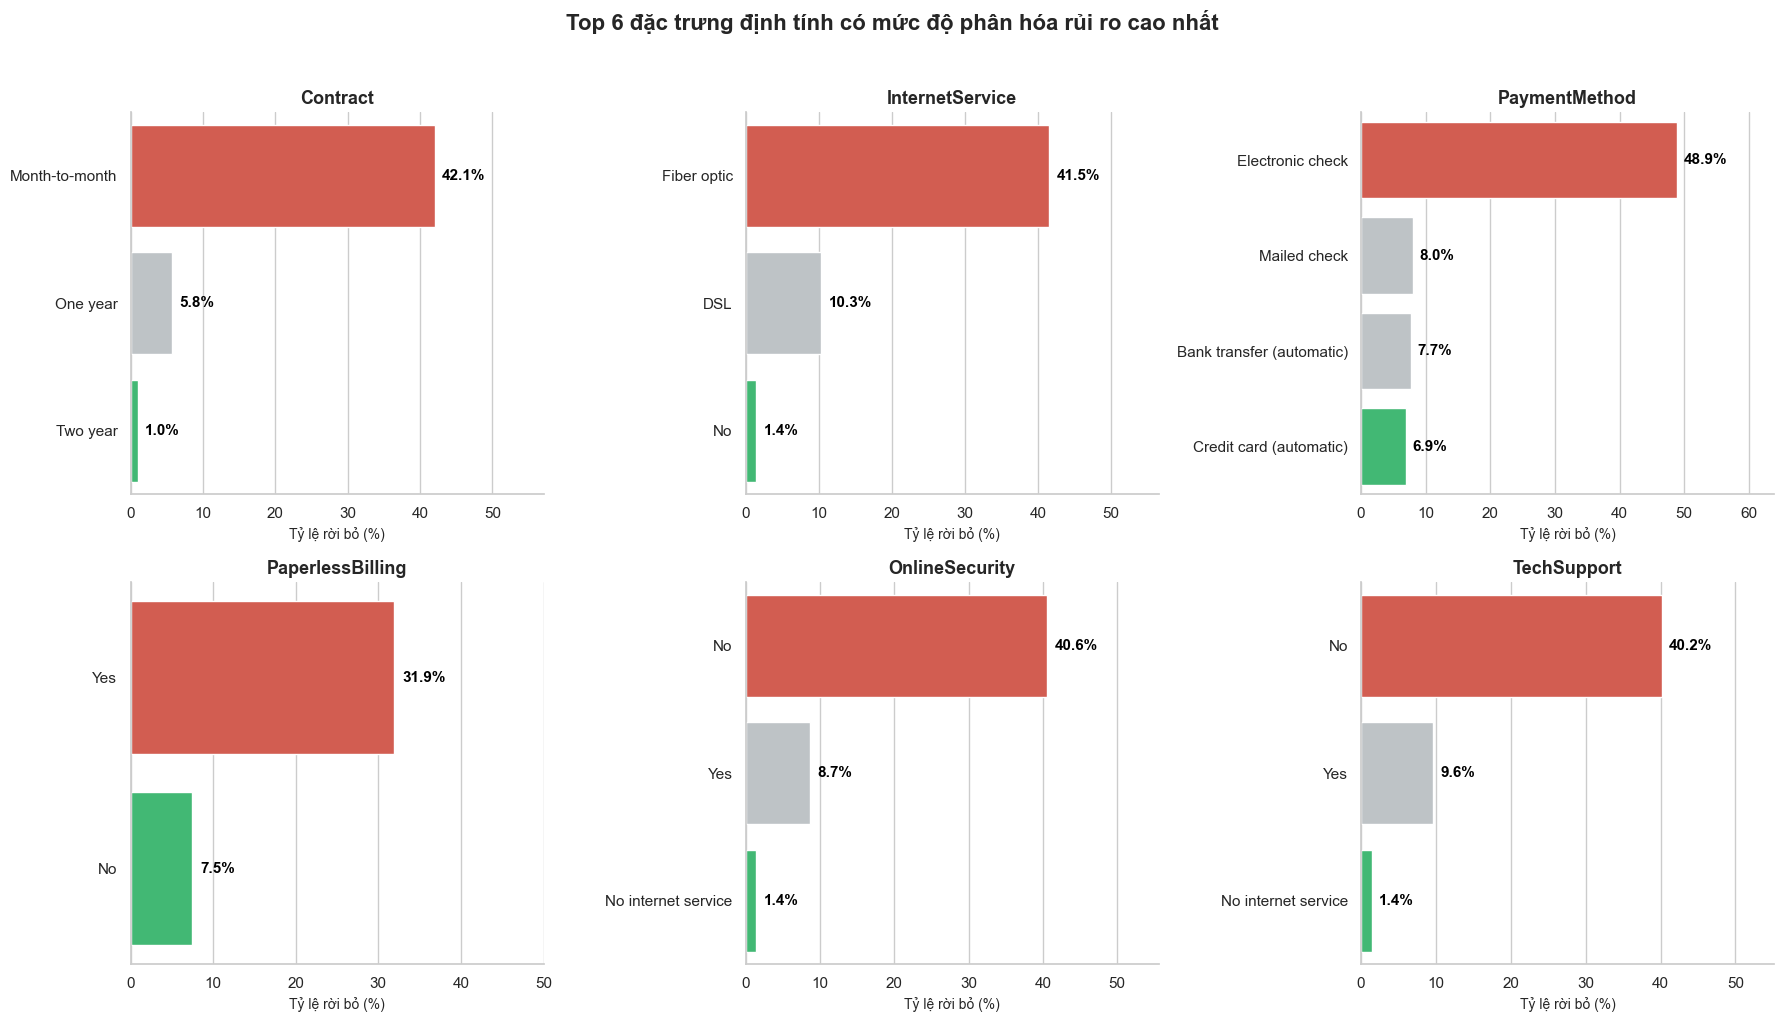

In [54]:
selected_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "OnlineSecurity",
    "TechSupport",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 

fig.suptitle("Top 6 đặc trưng định tính có mức độ phân hóa rủi ro cao nhất", fontsize=16, fontweight='bold', y=1.02)

for ax, feature in zip(axes.ravel(), selected_features):
    # logic tính toán dữ liệu của bạn giữ nguyên
    plot_data = (
        df_train_copy.groupby(feature, dropna=False)["churn_flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )
    
    risk_palette = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_data) - 1 else "#BDC3C7") for i in range(len(plot_data))]

    sns.barplot(
        data=plot_data, 
        y=feature, 
        x="churn_rate", 
        ax=ax,
        palette=risk_palette,
        hue=feature,
        legend=False
    )
    
    ax.set_title(feature, fontsize=13, fontweight='bold')
    ax.set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
    ax.set_ylabel("")

    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 15)) 
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', 
                    (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Nhận xét:** Việc dừng sử dụng dịch vụ của khách hàng, thông qua trực quan hóa, được thể hiện rõ qua 2 nhóm nguyên nhân cốt lõi:
-  Khách hàng sử dụng hình thức thanh toán ngắn hạn theo từng tháng *Month-to-month*, dùng mạng cáp quang tốc độ cao *Fiber optic*, hoặc thanh toán hóa đơn bằng séc điện tử *Electronic check* đều sở hữu tỷ lệ dừng đăng ký hợp đồng khá áp đảo. Tỷ lệ rủi ro của nhóm này nằm ở mức rất cao, từ $41.5\%$ đến $48.9\%$, chỉ ra rằng là những "điểm nghẽn" lớn nhất làm khách hàng hủy sử dụng dịch vụ.
- Với hai đặc trưng *OnlineSecurity* và *TechSupport*, nhóm khách hàng không đăng ký dịch vụ bảo mật hoặc hỗ trợ kỹ thuật *No* có tỷ lệ rời bỏ dịch vụ chạm ngưỡng $40.2\% - 40.6\%$. Ngược lại, nhóm có đăng ký *Yes* hoặc không dùng internet đều duy trì tỷ lệ hủy dịch vụ cực kỳ thấp, dưới $10\%$. Điều này chứng minh các dịch vụ bổ trợ giữ chân khách hàng cực kỳ hiệu quả.

**Kết luận:**
- Nhóm biểu đồ chứng minh các đặc trưng này có mối quan hệ mang tính phân tách nhóm rất rõ ràng. Việc chuyển đổi các thuộc tính này thành các biến định danh thông qua kỹ thuật *One-Hot Encoding* ở bước tiền xử lý sẽ giúp các mô hình học máy như **Tree-based models** hay **Logistic Regression** dễ dàng tìm ra các ngưỡng phân tách tối ưu.
- Thực hiện thiết lập các biến nhị phân cảnh báo, chẳng hạn như **high_risk_profile** nếu khách hàng thỏa mãn đồng thời các điều kiện có tỷ lệ dừng sử dụng dịch vụ cao như *Contract=="Month-to-month"* và *PaymentMethod == "Electronic check"*.
- Với các phân lớp có tỷ lệ churn tương đồng và rất thấp như nhóm *Two year* với $1.0\%$ hoặc nhóm *No internet service* với $1.4\%$, cân nhắc thực hiện gộp nhãn thành một nhóm an toàn chung nhằm giảm thiểu số chiều dữ liệu **Dimensionality Reduction** mà không làm mất đi sự tối ưu trong việc dự đoán của mô hình.

### 5.3 Xây dựng và Tinh chỉnh Đặc trưng (Feature Engineering)

**Note:** Mục tiêu của phần Kiến tạo Đặc trưng *Feature Engineering* là chuyển hóa các "manh mối" từ bước Khám phá *EDA* thành những tín hiệu rõ ràng và mạnh mẽ hơn cho mô hình *Machine Learning*. Quá trình này sẽ đi qua hai luồng xử lý chính: 
1. Rời rạc hóa không gian biến định lượng
2. Thiết lập các Cờ rủi ro *Risk Flags* cho nhóm biến định tính.


**Xây dựng và Rời rạc hóa biến Định lượng**

**Note:** Dựa trên phân phối của các biến định lượng đã biểu diễn ở phần $5.1$ để thực hiện rời rạc hóa *Discretization* nhằm làm rõ các ranh giới rủi ro:

In [55]:

df_train_copy['loyalty_tier'] = pd.cut(
    df_train_copy['tenure'], 
    bins=[0, 6, 12, 24, 48, float('inf')], 
    labels=['Onboarding', 'First Year', 'Second Year', 'Familiar', 'Loyal'],
    include_lowest=True
)

**Note:**  
**loyalty_tier:** Dựa trên các điểm rơi rủi ro của dịch vụ, độ gắn bó của khách hàng được chia thành $5$ mốc thời gian: *Onboarding $1-6$ tháng*, *First Year $7-12$ tháng*, *Second Year $13-24$ tháng*, *Established $2-4$ năm* và Loyal *trên $4$ năm*.

In [56]:
df_train_copy['charge_segment'] = pd.cut(
    df_train_copy['MonthlyCharges'], 
    bins=[0, 35, 70, float('inf')], 
    labels=['Budget', 'Standard', 'Premium'],
    include_lowest=True
)

**Note:**  
**charge_segment:** Mức cước phí hàng tháng được khoanh vùng theo ngưỡng chịu đựng tài chính, bao gồm $3$ mức: *Budget* $<35$ USD, *Standard $35-70$ USD*, *Premium $>70$ USD*.

In [57]:
conditions = [
    (df_train_copy['ExtraCharges'] < -75),
    (df_train_copy['ExtraCharges'] > 75)
]
choices = ['Discount/Downgraded', 'Upgraded/Surcharge']
df_train_copy['spending_shift'] = np.select(conditions, choices, default='Stable/No Changes')


**Note:**  
**spending_shift:** Những biến động chi phí ẩn được chia thành $3$ trạng thái: *Giảm giá/Giảm dịch vụ Discount/Downgraded*, *Ổn định Stable/No Changes* và *Nâng cấp/Phụ phí Upgraded/Surcharge*.

In [58]:
services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]
df_train_copy['total_services'] = (df_train_copy[services] == 'Yes').sum(axis=1)

**Note:**  
**total_services:** Định lượng trực tiếp bằng việc đếm tổng số dịch vụ bổ trợ được đăng kí sử dụng với mỗi khách hàng, từ $0$ đến $7$. 

**Trực quan hóa tác động của các Cặp Đặc trưng Định lượng mới lên Churn**

**Note:** Việc đánh giá độc lập từng biến đôi khi sẽ bỏ qua những điểm mù rủi ro. Bằng cách kết hợp chéo $4$ đặc trưng định lượng mới, các hiệu ứng tương tác kép *Interaction Effects* sẽ xuất hiện. Việc trực quan hoá nhằm tìm kiếm và phát hiện những tổ hợp đẩy tỷ lệ rời bỏ của khách hàng lên mức đỉnh điểm khi chúng cộng hưởng.

In [59]:
display_names = {
    'loyalty_tier': 'Độ gắn bó của khách hàng',
    'charge_segment': 'Mức cước phí hàng tháng',
    'spending_shift': 'Biến động chi phí ẩn',
    'total_services': 'Số lượng dịch vụ sử dụng'
}

**Note:** Thay đổi tên hiện thị trên biểu đồ cho các biến mới.

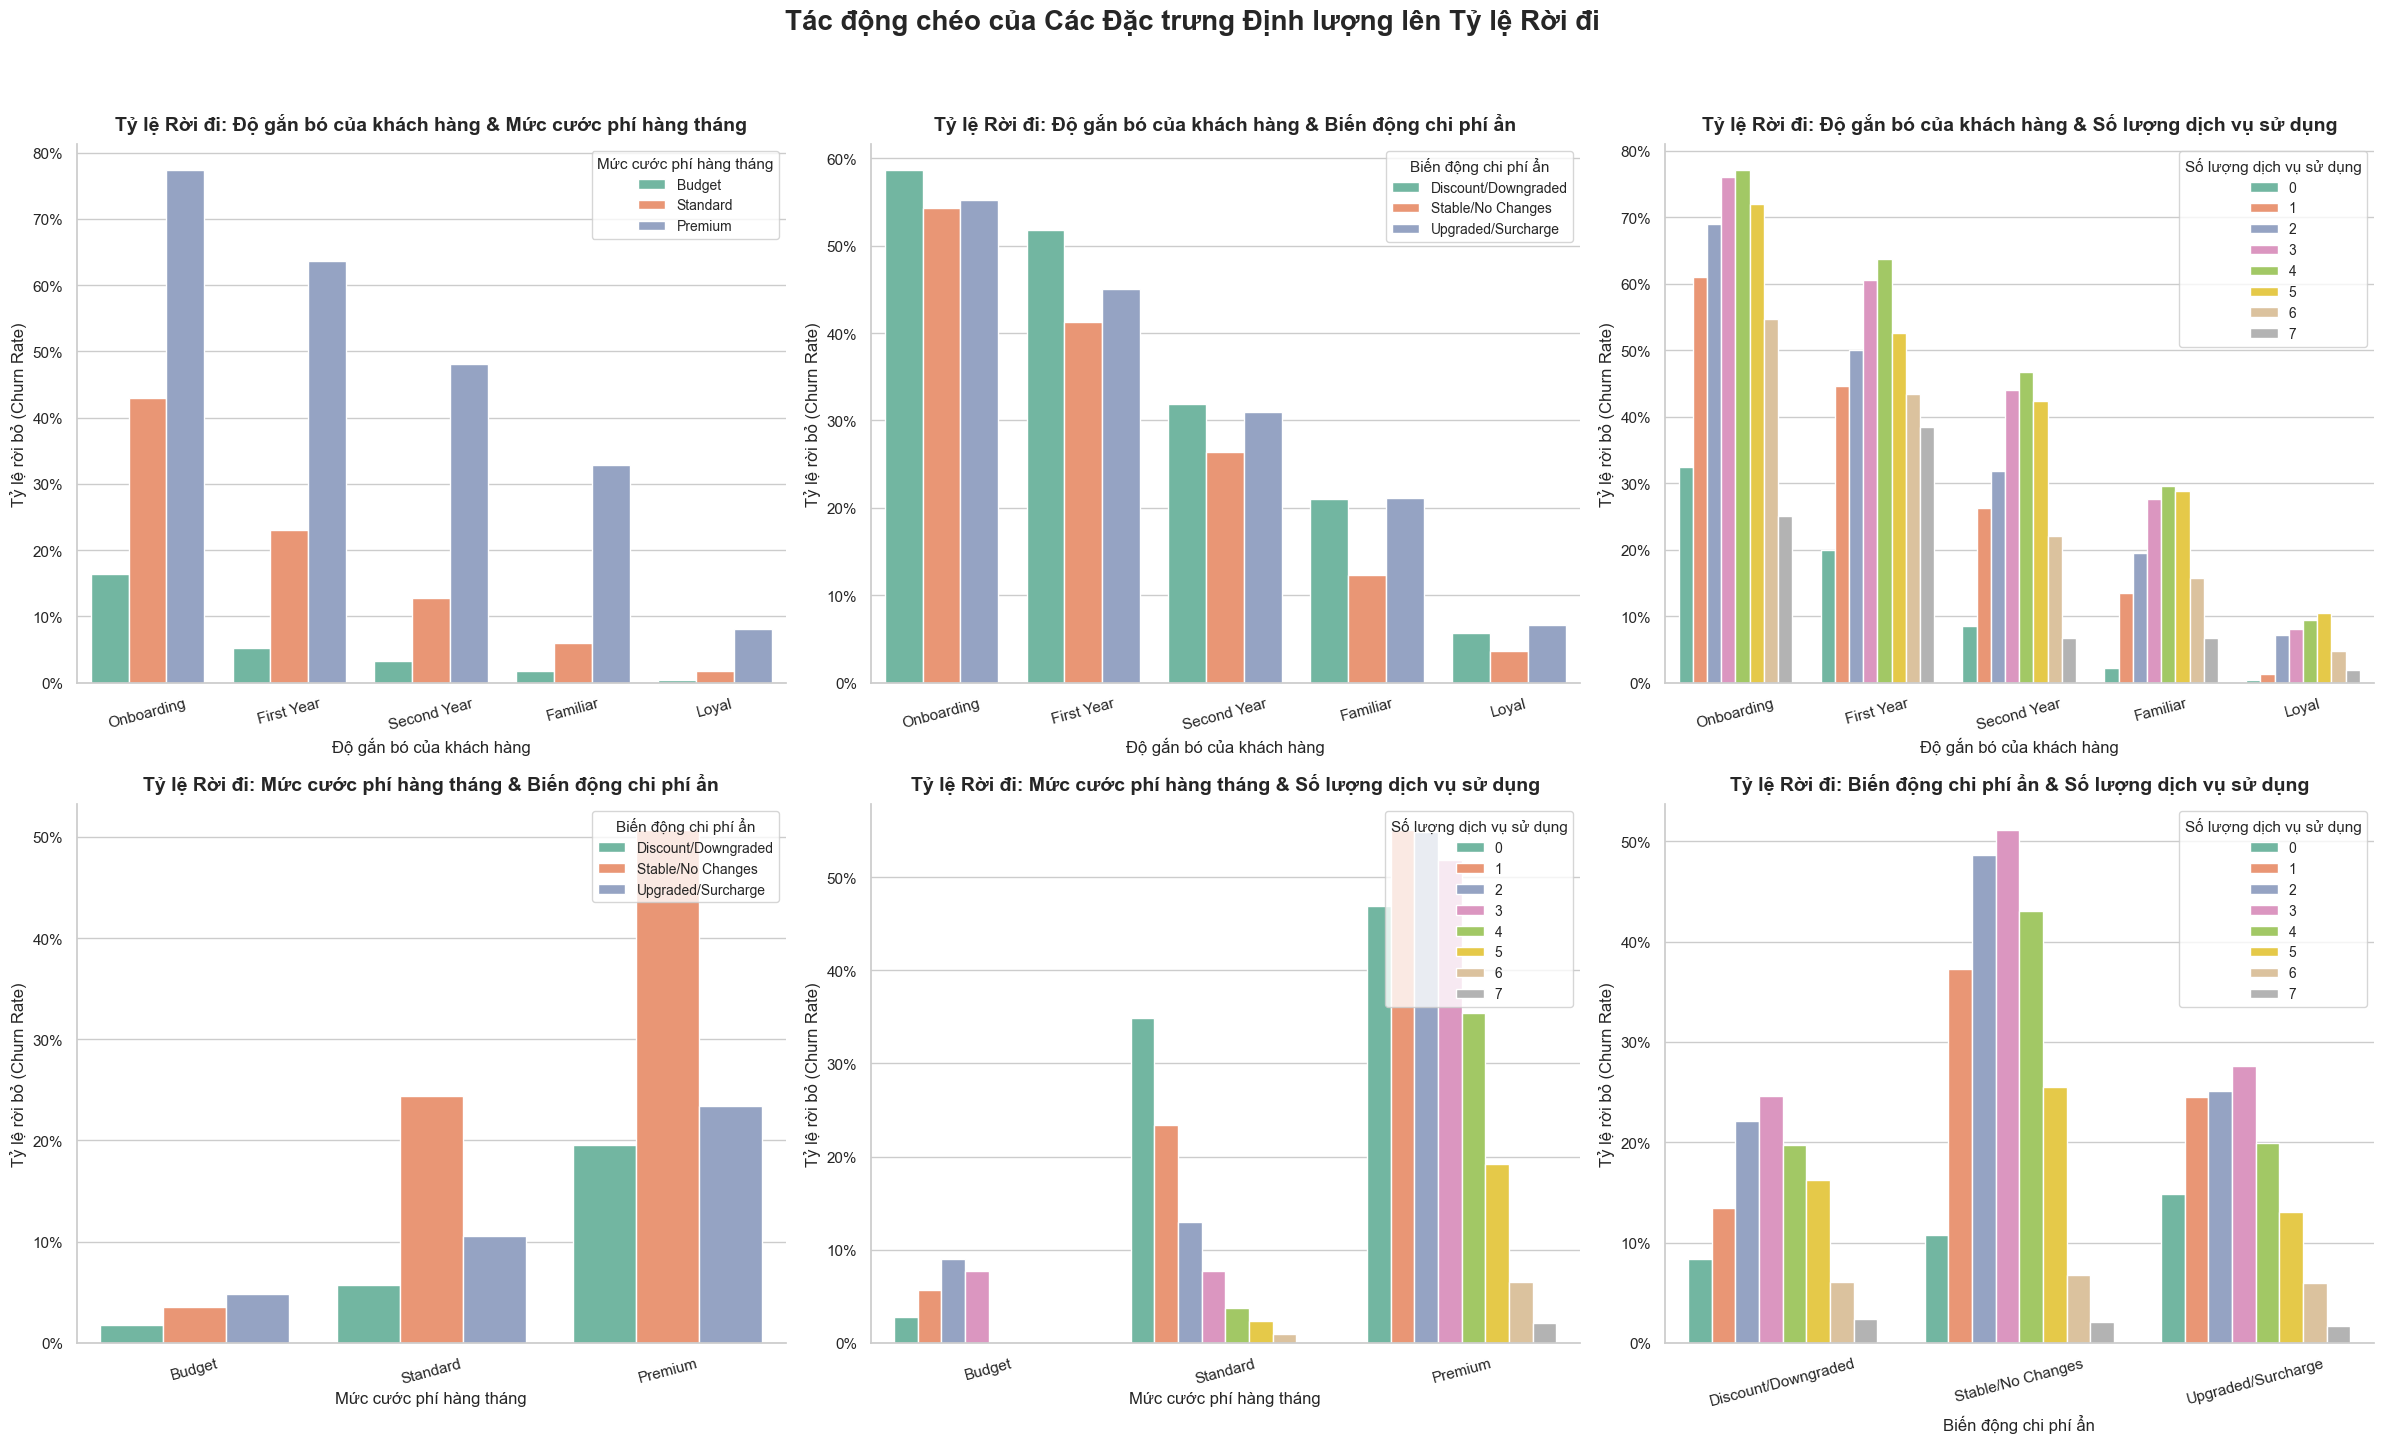

In [60]:
new_features = list(display_names.keys())
pairs = list(combinations(new_features, 2))

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle("Tác động chéo của Các Đặc trưng Định lượng lên Tỷ lệ Rời đi", 
             fontsize=20, fontweight='bold', y=1.03)

axes = axes.flatten()

for i, (feat1, feat2) in enumerate(pairs):
    ax = axes[i]
    
    name1 = display_names[feat1]
    name2 = display_names[feat2]
    
    sns.barplot(
        data=df_train_copy, 
        x=feat1, 
        y='churn_flag', 
        hue=feat2, 
        ax=ax,
        palette='Set2', 
        errorbar=None   
    )
    
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    ax.set_title(f"Tỷ lệ Rời đi: {name1} & {name2}", fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel("Tỷ lệ rời bỏ (Churn Rate)", fontsize=12)
    ax.set_xlabel(name1, fontsize=12)
    
    ax.tick_params(axis='x', rotation=15)
    
    ax.legend(title=name2, title_fontsize='11', fontsize='10', loc='upper right', bbox_to_anchor=(1, 1))
    
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Biểu đồ chỉ ra rằng *Nhóm khách hàng mới Onboarding* cực kỳ nhạy cảm về giá cả. Việc gánh chịu chi phí đắt đỏ từ mức cức phí cao nhất *Premium* khi mới đăng ký sử dụng dịch vụ khiến tỷ lệ rời bỏ tăng đến mức báo động, chạm ngưỡng $80\%$. Đáng chú ý, trong giai đoạn mới tiếp cận dịch vụ, sự biến động chi phí *Upgraded/Surcharge* và *Discount/Downgraded* đều khiến tâm lý khách hàng bất ổn, đẩy tỷ lệ dừng sử dụng dịch vụ lên mức rất cao trên $50\%$.
- Cặp Mức cước phí & Số lượng dịch vụ chỉ ra rằng nhóm khách hàng trả phí cao nhưng chỉ sử dụng số lượng dịch vụ thấp, từ $0$ đến $4$ dịch vụ bổ trợ có tỷ lệ dừng sử dụng dịch vụ dao động ở mức báo động đỏ từ $40\% - 60\%$. Khách hàng chỉ thực sự được giữ chân khi lượng dịch vụ sử dụng chạm mức bao phủ nhất định, từ $5$ đến $7$ dịch vụ.
- Ở chiều hướng khác, mức cước phí hàng tháng thấp *Budget* dưới $35$ USD và nhóm khách hàng từ giai đoạn quen thuộc *Familiar* trở lên có tỷ lệ rời bỏ dịch vụ rất thấp, gần như hoàn toàn miễn nhiễm với mọi biến động chi phí ẩn.

**Kết luận:**
- Các đặc trưng định lượng mới **loyalty_tier**, **charge_segment**, **spending_shift**, **total_services** đã chứng minh được giá trị vượt trội trong việc bóc tách rủi ro. Thay vì góc nhìn đơn lẻ, việc phân tích tương tác chéo giữa các biến này đã giúp hệ thống nhận diện thành công những quy luật hành vi cốt lõi. 
- Vì tính hữu dụng của chúng, ta thực hiện đưa các chúng vào danh sách biến huấn luyện cho mô hình học máy **Machine Learning**, đồng thời đưa các biến định lượng gốc tương ứng  **tenure**, **MonthlyCharges**, **ExtraCharges** vào danh sách chờ loại bỏ *Drop* ở bước tiền xử lý cuối cùng, nhằm tinh gọn dữ liệu và triệt tiêu hoàn toàn rủi ro đa cộng tuyến *Multicollinearity*.

**Tinh chỉnh Đặc trưng Định tính & Gắn cờ Rủi ro (Risk Flagging)**

**Note:** Thay vì mã hóa toàn bộ các biến phân loại một cách cồng kềnh, chiến lược tối ưu ở đây là *Khoanh vùng và Cô lập*. Những danh mục có tỷ lệ ngừng sử dụng dịch vụ vượt ngưỡng báo động sẽ được trích xuất thành các Cờ rủi ro nhị phân *Risk Flags*. Điều này giúp mô hình tập trung trực tiếp vào các tín hiệu cảnh báo đỏ mà không bị nhiễu bởi các nhóm an toàn.

In [61]:
cat_churn_rows = []

for col in categorical_features:
    tmp = (
        df_train_copy.groupby(col, dropna=False)
        .agg(count=("churn_flag", "size"), churn_rate=("churn_flag", "mean"))
        .reset_index()
        .rename(columns={col: "Giá trị (Category)"})
    )
    
    tmp["Đặc trưng gốc"] = col
    tmp["Tổng số khách hàng"] = tmp["count"]
    tmp["Tỷ lệ khách hàng"] = (tmp["count"] / len(df_train_copy)) * 100
    tmp["Tỷ lệ rời đi"] = tmp["churn_rate"] * 100
    
    cat_churn_rows.append(tmp[["Đặc trưng gốc", "Giá trị (Category)", "Tổng số khách hàng", "Tỷ lệ khách hàng", "Tỷ lệ rời đi"]])

global_risk_board = pd.concat(cat_churn_rows, ignore_index=True)
top_risk_categories = global_risk_board.sort_values("Tỷ lệ rời đi", ascending=False).head(20)

display(top_risk_categories.style.format({'Tỷ lệ khách hàng': '{:.2f}%', 'Tỷ lệ rời đi': '{:.1f}%'}).hide(axis="index"))

Đặc trưng gốc,Giá trị (Category),Tổng số khách hàng,Tỷ lệ khách hàng,Tỷ lệ rời đi
SeniorCitizen,Yes,67799,11.41%,50.0%
PaymentMethod,Electronic check,215372,36.25%,48.9%
Contract,Month-to-month,298918,50.31%,42.1%
InternetService,Fiber optic,272386,45.84%,41.5%
OnlineSecurity,No,289474,48.72%,40.6%
TechSupport,No,288571,48.57%,40.2%
OnlineBackup,No,250083,42.09%,39.1%
DeviceProtection,No,247377,41.63%,38.1%
Partner,No,284640,47.90%,32.5%
PaperlessBilling,Yes,365579,61.53%,31.9%


**Nhận xét:**
- *Người cao tuổi SeniorCitizen = Yes* có tỷ lệ dừng sử dụng dịch vụ cao nhất $50.0\%$. Tuy nhiên, nếu đối chiếu với quy mô, nhóm này chỉ chiếm $11.41\%$ tổng lượng khách hàng. Đây là một cái bẫy thống kê kinh điển: Một rủi ro cao trên một tập khách hàng nhỏ sẽ ít gây sát thương hơn một rủi ro trung bình trên một tập khách hàng khổng lồ.
- Do đó, để mô hình học máy *Machine Learning* tập trung vào nhóm rủi ro thực sự, ta ưu tiên gắn Cờ rủi ro *Risk Flags* cho những hạng mục thỏa mãn cả $2$ điều kiện: Tỷ lệ rời đi vượt ngưỡng báo động, chẳng hạn như $> 40\%$ và chiếm tỷ trọng khách hàng lớn, hơn $30\%$ khách hàng. Dựa trên tiêu chí này, các nhóm rủi ro thực sự cần được chú ý bao gồm:
    - *Contract = Month-to-month* chiếm $50.3\%$ khách hàng, tỷ lệ dừng sử dụng dịch vụ đạt $42.1\%$
    - *PaymentMethod = Electronic check* chiếm $36.3\%$ khách hàng, tỷ lệ dừng sử dụng dịch vụ đạt $48.9\%$
    - *InternetService = Fiber optic* chiếm	$45.84\%$ khách hàng, tỷ lệ dừng sử dụng dịch vụ đạt $41.5\%$
    - Các dịch vụ bổ trợ *OnlineSecurity = No*, *TechSupport = No* cũng xuất hiện ở nhóm rủi ro cao. Tuy nhiên, thay vì cắm cờ đơn lẻ cho từng dịch vụ không sử dụng, ta sử dụng phương pháp Phân tích Chênh lệch **Gap Analysis** ở bước tiếp theo để tìm ra dịch vụ giữ chân khách hàng tốt nhất.

**Trực quan hóa Phân tích Chênh lệch Tỷ lệ Rời bỏ theo các dịch vụ**

In [62]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

**Note:** Liệt kê các gói dịch vụ đi kèm các dịch vụ chính.

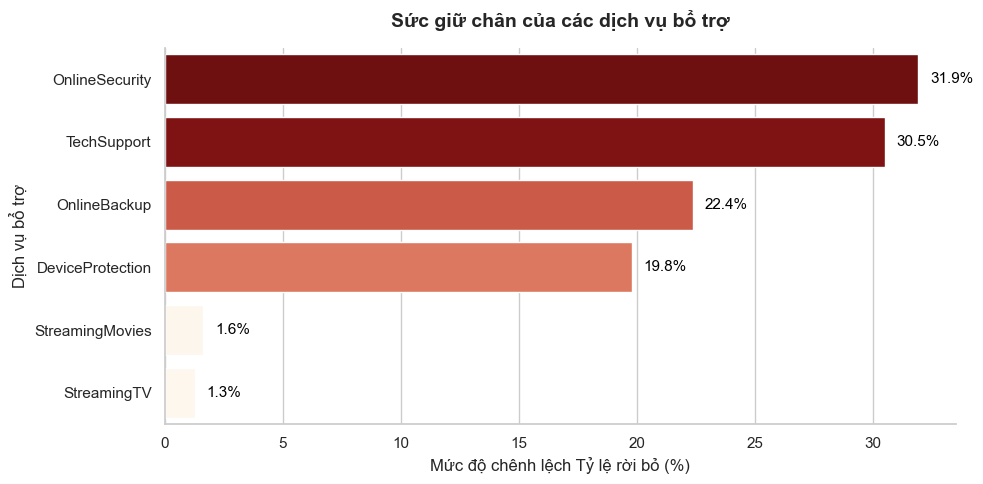

Dịch vụ,Tỷ lệ rời bỏ khi không sử dụng dịch vụ,Tỷ lệ rời bỏ khi sử dụng dịch vụ,Độ chênh lệch
OnlineSecurity,40.6%,8.7%,31.9%
TechSupport,40.2%,9.6%,30.5%
OnlineBackup,39.1%,16.7%,22.4%
DeviceProtection,38.1%,18.3%,19.8%
StreamingMovies,29.9%,28.3%,1.6%
StreamingTV,29.7%,28.5%,1.3%


In [63]:
gap_rows = []

for col in service_cols:
    churn_yes = df_train_copy[df_train_copy[col] == 'Yes']['churn_flag'].mean() * 100
    churn_no = df_train_copy[df_train_copy[col] == 'No']['churn_flag'].mean() * 100
    gap_rows.append({
        "Dịch vụ": col,
        "Tỷ lệ rời bỏ khi không sử dụng dịch vụ": churn_no,
        "Tỷ lệ rời bỏ khi sử dụng dịch vụ": churn_yes,
        "Độ chênh lệch": churn_no - churn_yes
    })

gap_df = pd.DataFrame(gap_rows).sort_values("Độ chênh lệch", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=gap_df, y="Dịch vụ", x="Độ chênh lệch", palette="OrRd", hue="Độ chênh lệch", dodge=False, legend=False)


plt.title("Sức giữ chân của các dịch vụ bổ trợ", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mức độ chênh lệch Tỷ lệ rời bỏ (%)", fontsize=12)
plt.ylabel("Dịch vụ bổ trợ", fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.1f}%',
                       (p.get_width() + 0.5, p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', fontsize=11, color='black')
sns.despine()
plt.tight_layout()
plt.show()

display(gap_df.style.format({'Tỷ lệ rời bỏ khi không sử dụng dịch vụ': '{:.1f}%', 'Tỷ lệ rời bỏ khi sử dụng dịch vụ': '{:.1f}%', 'Độ chênh lệch': '{:.1f}%'}).hide(axis="index"))

**Nhận xét:**
- Biểu đồ độ chỉ ra rõ ràng hai dịch vụ mang tính giữ chân cao nhất là **Hỗ trợ kỹ thuật TechSupport** và **Bảo mật trực tuyến OnlineSecurity**. Việc khách hàng không sở hữu hai dịch vụ này khiến tỷ lệ rời bỏ tăng vọt, thể hiện thông qua độ chênh lệch lên đến $15\% - 22\%$ so với người có đăng ký dịch vụ. Đây chính là lỗ hổng dịch vụ nguy hiểm nhất.
- Ngược lại, các dịch vụ giải trí như **StreamingTV** hay **StreamingMovies** mang lại độ chênh lệch rủi ro rất thấp. Việc khách hàng có xem TV/Phim hay không gần như không tác động đáng kể đến quyết định dừng đăng kí hợp đồng đi của họ.

In [64]:
df_train_copy = df_train_copy.assign(
    flag_month_to_month = (df_train_copy["Contract"] == "Month-to-month").astype(int),
    flag_electronic_check = (df_train_copy["PaymentMethod"] == "Electronic check").astype(int),
    flag_fiber_optic = (df_train_copy["InternetService"] == "Fiber optic").astype(int),
    
    flag_no_tech_support = (df_train_copy["TechSupport"] == "No").astype(int),
    flag_no_online_security = (df_train_copy["OnlineSecurity"] == "No").astype(int),
    
    flag_high_risk_profile = lambda x: (
        (x["Contract"] == "Month-to-month") & 
        (x["InternetService"] == "Fiber optic") & 
        (x["PaymentMethod"] == "Electronic check")
    ).astype(int)
)

*Nhận xét:* Các cờ rủi ro nhị phân *Risk Flag* bao gồm:
- Nhóm cờ rủi ro cơ bản dựa trên tỷ lệ rời bỏ dịch vụ cao):
    - **flag_month_to_month**: Khách hàng sử dụng hợp đồng ngắn hạn từng tháng
    - **flag_electronic_check**: Khách hàng thanh toán qua Séc điện tử
    - **flag_fiber_optic**: Khách hàng sử dụng đường truyền Cáp quang

- Nhóm cờ Lỗ hổng dịch vụ dựa trên *Gap Analysis*:
    - **flag_no_tech_support**: Khách hàng trần trụi, KHÔNG có Hỗ trợ kỹ thuật
    - **flag_no_online_security**: Khách hàng trần trụi, KHÔNG có Bảo mật trực tuyến

- Đặc trưng Tổ hợp *Composite Feature*:
    - **flag_high_risk_profile**: Siêu cờ rủi ro (Nhận diện khách hàng mang thiết lập độc hại nhất: Trả từng tháng + Dùng Cáp quang + Trả bằng Séc điện tử).

**Kết luận:**  
Thông qua quá trình xử lý linh hoạt — rời rạc hóa các biến định lượng và phân tích chênh lệch *Gap Analysis* các biến định tính — những rủi ro tiềm ẩn của hệ sinh thái đã được định lượng hóa thành các Cờ rủi ro *Risk Flags* và Đặc trưng tổ hợp *Composite Features*. Tập dữ liệu gốc `df_train_copy` được bảo toàn trọn vẹn, đồng thời cung cấp một bộ đặc trưng mới sắc bén hơn, sạch nhiễu hơn, sẵn sàng để bước vào giai đoạn Phân tích Tương quan và Huấn luyện mô hình.

### 5.4 Phân tích tương quan (Correlation Analysis)

**Note:** Sau khi hoàn tất quá trình Khai phá và Biến đổi đặc trưng *Feature Engineering*, bước Phân tích Tương quan *Correlation Analysis* đóng vai trò như lưới lọc *filter* cuối cùng và nghiêm ngặt nhất, với $4$ nhiệm vụ cốt lõi:
- Tối ưu hóa Phương pháp Thống kê: Áp dụng Cramér's V để khám phá biến định tính nguyên bản, Pearson cho các biến định lượng/nhị phân, và Spearman để đo lường xu hướng thứ bậc. Việc này tránh sai số toán học khi đánh giá chéo các kiểu dữ liệu khác nhau.
- Kiểm định Đặc trưng *Feature Validation*: So sánh chất lượng *Risk Flags* và Đặc trưng tổ hợp với các Đặc trưng gốc về sự tiệm cận nguyên nhân cốt lõi dẫn đến sự rời bỏ khách hàng, thông qua hệ số tương quan đã được tính trước đó
- Sàng lọc Đa cộng tuyến *Multicollinearity Check*: Phát hiện và cô lập các biến độc lập có độ trùng lặp thông tin quá lớn, giúp giảm nhiễu và ngăn chặn sự sai lệch trọng số trong mô hình.
- Hoàn thành danh sách Đặc trưng (Final Feature Selection): Rút trích ra bộ tính năng *features* ưu tú và tinh gọn nhất, giữ lại những tín hiệu dự đoán mạnh mẽ nhất nhằm chuẩn bị cho các khâu kiểm thử *Test Drift* phía sau

**Khám phá Tương quan Biến định tính nguyên bản so với Churn(Cramér's V)**

*Note:* *Hệ số Pearson* truyền thống không thể áp dụng cho các biến phân loại nguyên bản mang giá trị chuỗi văn bản như *Contract*, *InternetService*, *PaymentMethod*. Thay cho phương pháp mặc định, chúng ta sử dụng *Cramér's V* — một thước đo thống kê dựa trên *Kiểm định Chi-bình phương ($\chi^2$)* nhằm định lượng sức mạnh liên kết giữa hai biến danh nghĩa (Nominal variables).

In [65]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    min_dim = min((kcorr-1), (rcorr-1))
    if min_dim == 0:
        return 0
    return np.sqrt(phi2corr / min_dim)

**Note:** Công thức cơ sở:  
$V = \sqrt{\frac{\chi^2 / n}{\min(k-1, r-1)}}$

In [66]:
cramer_rows = []
for col in categorical_features:
    if col in df_train_copy.columns:
        score = cramers_v(df_train_copy[col], df_train_copy['churn_flag'])
        cramer_rows.append({
            "Đặc trưng": col,
            "Hệ số Cramér's V": score
        })

df_cramer = pd.DataFrame(cramer_rows).sort_values("Hệ số Cramér's V", ascending=False)

**Note:** Tạo *DataFrame* chứa đặc trưng định tính nguyên bản và hệ số tương quan tương ứng

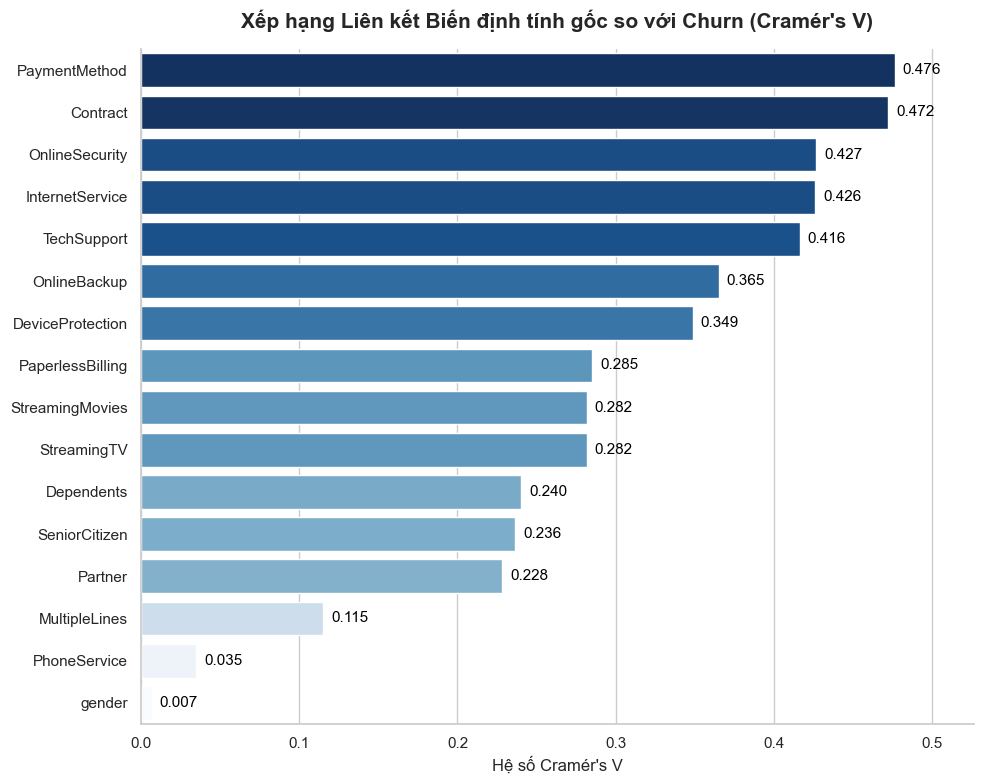

In [67]:


plt.figure(figsize=(10, 8))
sns.barplot(data=df_cramer, y="Đặc trưng", x="Hệ số Cramér's V", 
            palette="Blues", hue="Hệ số Cramér's V", dodge=False, legend=False)

plt.title("Xếp hạng Liên kết Biến định tính gốc so với Churn (Cramér's V)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Hệ số Cramér's V", fontsize=12)
plt.ylabel("")

plt.xlim(0, df_cramer["Hệ số Cramér's V"].max() + 0.05)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.3f}', 
                       (p.get_width() + 0.005, p.get_y() + p.get_height() / 2.), 
                       ha='left', va='center', fontsize=11, color='black')

sns.despine()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Nhóm *Thông tin Giao dịch/Hợp đồng* **PaymentMethod**, **Contract** và *Dịch vụ Internet/Bảo mật* **OnlineSecurity**, **InternetService**, **TechSupport** đứng đầu bảng xếp hạng với hệ số tương quan rất cao $V > 0.4$. Điều này chứng tỏ quyết định xây dựng các Cờ rủi ro *Risk Flags* như **flag_month_to_month** hay **flag_electronic_check** là hoàn toàn chuẩn xác
- Biến *Nhân khẩu học gender* $0.007$ và các dịch vụ thoại cơ bản như *PhoneService* $0.035$, *MultipleLines* $0.115$ có hệ số tương quan với Churn gần như bằng 0. Tín hiệu này cho phép chúng ta loại bỏ các biến này ở khâu hoàn thành danh sách cuối cùng để giúp mô hình học nhanh và tránh nhiễu.

**Khám phá Tương quan Biến Định lượng nguyên bản so với Churn (Pearson)**

**Note:** Nếu *Cramér's V* là thước đo chuyên dụng cho biến định tính, thì đối với nhóm biến định lượng liên tục nguyên bản **tenure**, **MonthlyCharges**, **TotalCharges**, ta sử dụng *Hệ số tương quan Pearson $r$* làm tiêu chuẩn đánh giá. Việc lập ma trận tương quan ở bước này phục vụ $2$ mục tiêu quan trọng:
- Kiểm soát Đa cộng tuyến *Multicollinearity*: Rà soát độ chồng chéo thông tin giữa các biến độc lập
- Đo lường *Lực đẩy/Lực giữ*: Thực hiện xác định tác động thuận hay nghịch của các biến định lượng nguyên bản đến quyết định rời bỏ dịch vụ, từ đó đưa ra quyết định giữ hay loại bỏ biến gốc trước khi đưa vào mô hình.

**Note:** Công thức cơ sở:  

$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$.  

Hệ số Pearson dao động từ $-1$ tương quan nghịch hoàn hảo đến 1 tương quan thuận hoàn hảo. Đối với các biến mang giá trị số học liên tục *continuous variables*, *hệ số Pearson* là công cụ đo lường quan hệ tuyến tính nhạy bén nhất. Nó giúp lượng hóa chính xác tỷ lệ thuận/nghịch giữa chi phí, thời gian với tỷ lệ rời bỏ, đồng thời là "máy quét" tiêu chuẩn để phát hiện *Đa cộng tuyến* – yếu tố gây nhiễu trọng số lớn nhất của các mô hình Machine Learning sau này.

In [68]:
quant_features = numerical_features + ['churn_flag']

corr_quant = (
    df_train_copy[quant_features]
    .rename(columns={'churn_flag': 'ChurnFlag', 'tenure': 'Tenure'})
    .corr()
)

**Note:** Tạo *DataFrame* chứa đặc trưng định lượng nguyên bản và hệ số tương quan tương ứng

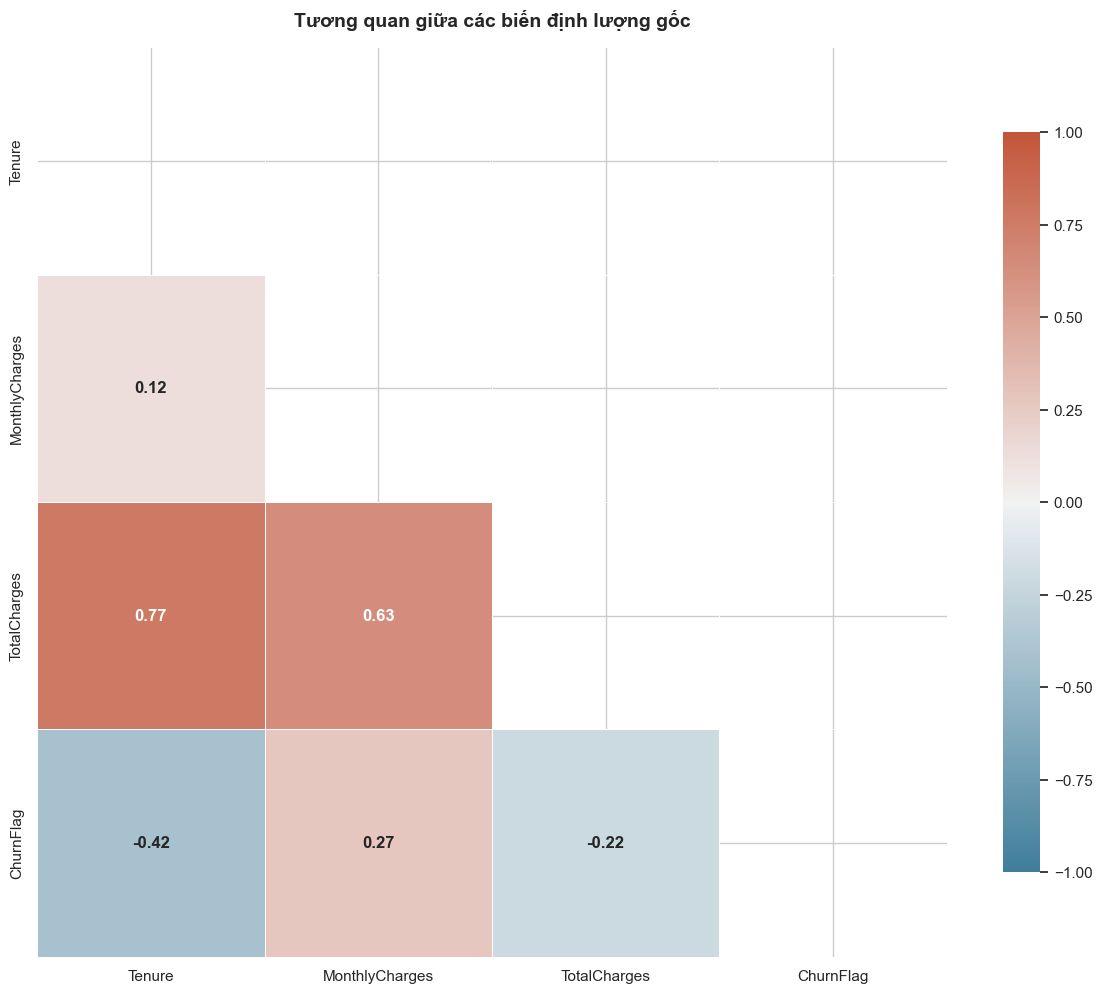

In [69]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_quant, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_quant, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt='.2f', square=True, linewidths=.5, 
    cbar_kws={"shrink": .8}, annot_kws={"size": 12, "fontweight": "bold"} 
)

plt.title("Tương quan giữa các biến định lượng gốc", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét:**
- **TotalCharges** có độ tương quan rất cao với tenure $0.77$ và MonthlyCharges $0.63$. Về bản chất, *Tổng chi phí* được tính dựa trên *Thời gian sử dụng* và *Phí hàng tháng*. Để tránh làm nhiễu mô hình và tối ưu hóa số chiều dữ liệu, ta loại bỏ **TotalCharges** ra khỏi danh sách đặc trưng cuối cùng.
- **tenure** $-0.42$ là nhân tố giữ chân khách hàng mạnh mẽ nhất trong nhóm định lượng, trong khi **MonthlyCharges** $0.27$ là yếu tố khiến khách hàng rời bỏ dịch vụ. Cả hai biến này đều chứa tín hiệu tốt và sẽ được giữ lại.

**Khám phá Tương quan Xu hướng Thứ bậc so với Churn (Spearman)**

**Note:** Đối với các đặc trưng mang tính thứ bậc *Ordinal Variables* như các nhóm phân khúc **loyalty_tier**, **charge_segment**, **spending_shift** hoặc biến đếm số lượng dịch vụ **total_services**, *hệ số Pearson* sẽ không đạt hiệu quả tối ưu do bản chất các khoảng cách không thực sự tuyến tính hoàn hảo. Thay vào đó, chúng ta sử dụng Hệ số tương quan hạng Spearman ($\rho$).

**Note:** Công thức cơ sở

$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$

Hệ số Spearman đo lường mối quan hệ đơn điệu *monotonic*: Khi giá trị của biến này tăng lên thứ hạng cao hơn, liệu rủi ro rời bỏ dịch vụ có tăng hoặc giảm theo một chiều hướng nhất định hay không? Kết quả từ bước này giúp đánh giá trực tiếp hiệu quả của việc phân nhóm dữ liệu *Binning* ở bước Khai phá đặc trưng *Feature Engineering*.

In [70]:
ordinal_mappings = {
    'loyalty_tier': {'Onboarding': 1, 'First Year': 2, 'Second Year': 3, 'Familiar': 4, 'Loyal': 5},
    'charge_segment': {'Budget': 1, 'Standard': 2, 'Premium': 3},
    'spending_shift': {'Discount/Downgraded': 1, 'Stable/No Changes': 2, 'Upgraded/Surcharge': 3}
}

**Note:** Thực hiện xếp hạng các biến tương ứng để tính *Hệ số Spearman*

In [71]:
spearman_rows = []

for col in new_features:
    if col in ordinal_mappings:
        numeric_series = df_train_copy[col].map(ordinal_mappings[col])
    else:
        numeric_series = df_train_copy[col]
    score = numeric_series.astype(float).corr(df_train_copy['churn_flag'], method='spearman')
    spearman_rows.append({
        "Đặc trưng": display_names.get(col, col),
        "Hệ số Spearman": score
    })

df_spearman = pd.DataFrame(spearman_rows).sort_values("Hệ số Spearman", ascending=False)

**Note:** Tạo *DataFrame* chứa đặc trưng xu hướng thứ bậc và hệ số tương quan tương ứng

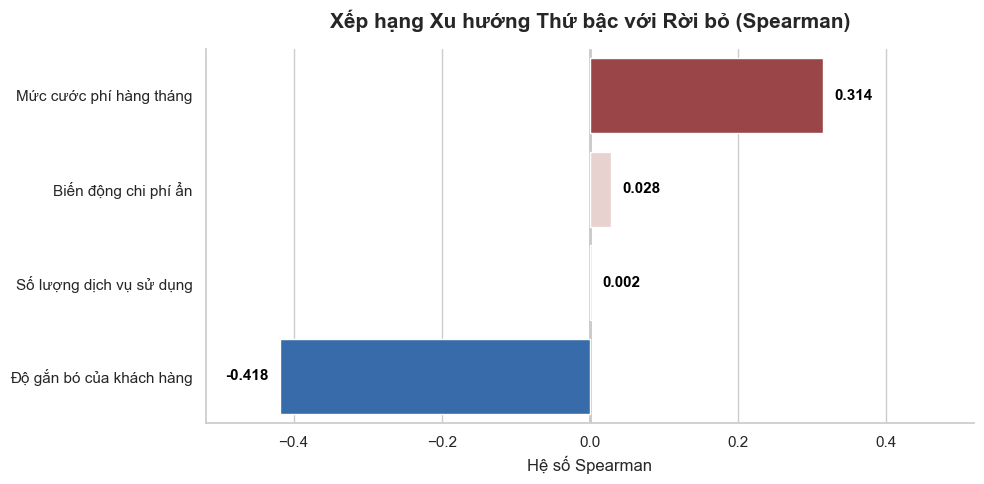

In [72]:
plt.figure(figsize=(10, 5)) 

sns.barplot(data=df_spearman, y="Đặc trưng", x="Hệ số Spearman", 
            palette="vlag", hue="Hệ số Spearman", dodge=False, legend=False)

plt.title("Xếp hạng Xu hướng Thứ bậc với Rời bỏ (Spearman)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Hệ số Spearman", fontsize=12)
plt.ylabel("")


for p in plt.gca().patches:
    val = p.get_width()
    offset = 0.015 if val > 0 else -0.015
    ha_align = 'left' if val > 0 else 'right'
    
    plt.gca().annotate(f'{val:.3f}', 
                       (val + offset, p.get_y() + p.get_height() / 2.), 
                       ha=ha_align, va='center', fontsize=11, color='black', fontweight='bold')

max_abs = df_spearman["Hệ số Spearman"].abs().max() + 0.1
plt.xlim(-max_abs, max_abs)

sns.despine()
plt.axvline(x=0, color='#000000', linewidth=1, linestyle='-', zorder=0)
plt.tight_layout()
plt.show()

**Khám phá Tương quan Cờ rủi ro so với Churn (Pearson)**

**Nhận xét:** Biểu đồ trực quan ma trận tương quan ở bước này phục vụ $2$ mục tiêu cốt lõi:
- Kiểm chứng các biến mới *Feature Validation*: Xác nhận các *Risk Flags* thực sự tiệm cận nguyên nhân cốt lõi dẫn đến sự rời bỏ của khách hàng, thể hiện qua hệ số tương quan dương rõ rệt với **churn_flag**.
- Kiểm soát Đa cộng tuyến *Multicollinearity Check*: Giám sát chặt chẽ tương quan nội bộ giữa các biến, đặc biệt là giữa Siêu cờ tổ hợp *flag_high_risk_profile* và các cờ thành phần tạo nên nó. Mục tiêu là đảm bảo việc gộp biến sinh ra giá trị gia tăng chứ không vi phạm quy tắc trùng lặp dữ liệu, với ngưỡng an toàn hệ số $< 0.8$.

**Note:** Ta tiếp tục sử dụng *Phương pháp Pearson* để đánh giá Cờ rủi ro *Risk Flags*. Về mặt toán học, khi áp dụng hệ số $Pearson$ cho các biến chỉ mang giá trị nhị phân, công thức sẽ tương đương với Hệ số Phi ($\phi$) — thước đo chuẩn mực và tối ưu nhất để đánh giá sự tương quan của các biến nhị phân.

In [73]:
risk_features = [
    'flag_month_to_month', 'flag_electronic_check', 'flag_fiber_optic', 
    'flag_no_tech_support', 'flag_no_online_security', 'flag_high_risk_profile',
    'churn_flag'
]

rename_map = {
    'flag_month_to_month': 'Flag Month-to-Month',
    'flag_electronic_check': 'Flag Electronic Check',
    'flag_fiber_optic': 'Flag Fiber Optic',
    'flag_no_tech_support': 'Flag No Tech Support',
    'flag_no_online_security': 'Flag No Online Security',
    'flag_high_risk_profile': 'Flag High Risk Profile',
    'churn_flag': 'ChurnFlag'
}

**Note:** Liệt kê các *Risk Flags* và đổi tên tương ứng để hiển thị

In [74]:
corr_risk = (
    df_train_copy[risk_features]
    .rename(columns=rename_map)
    .corr()
)

**Note:** Tạo *DataFrame* chứa *Risk Flags* và hệ số tương quan tương ứng

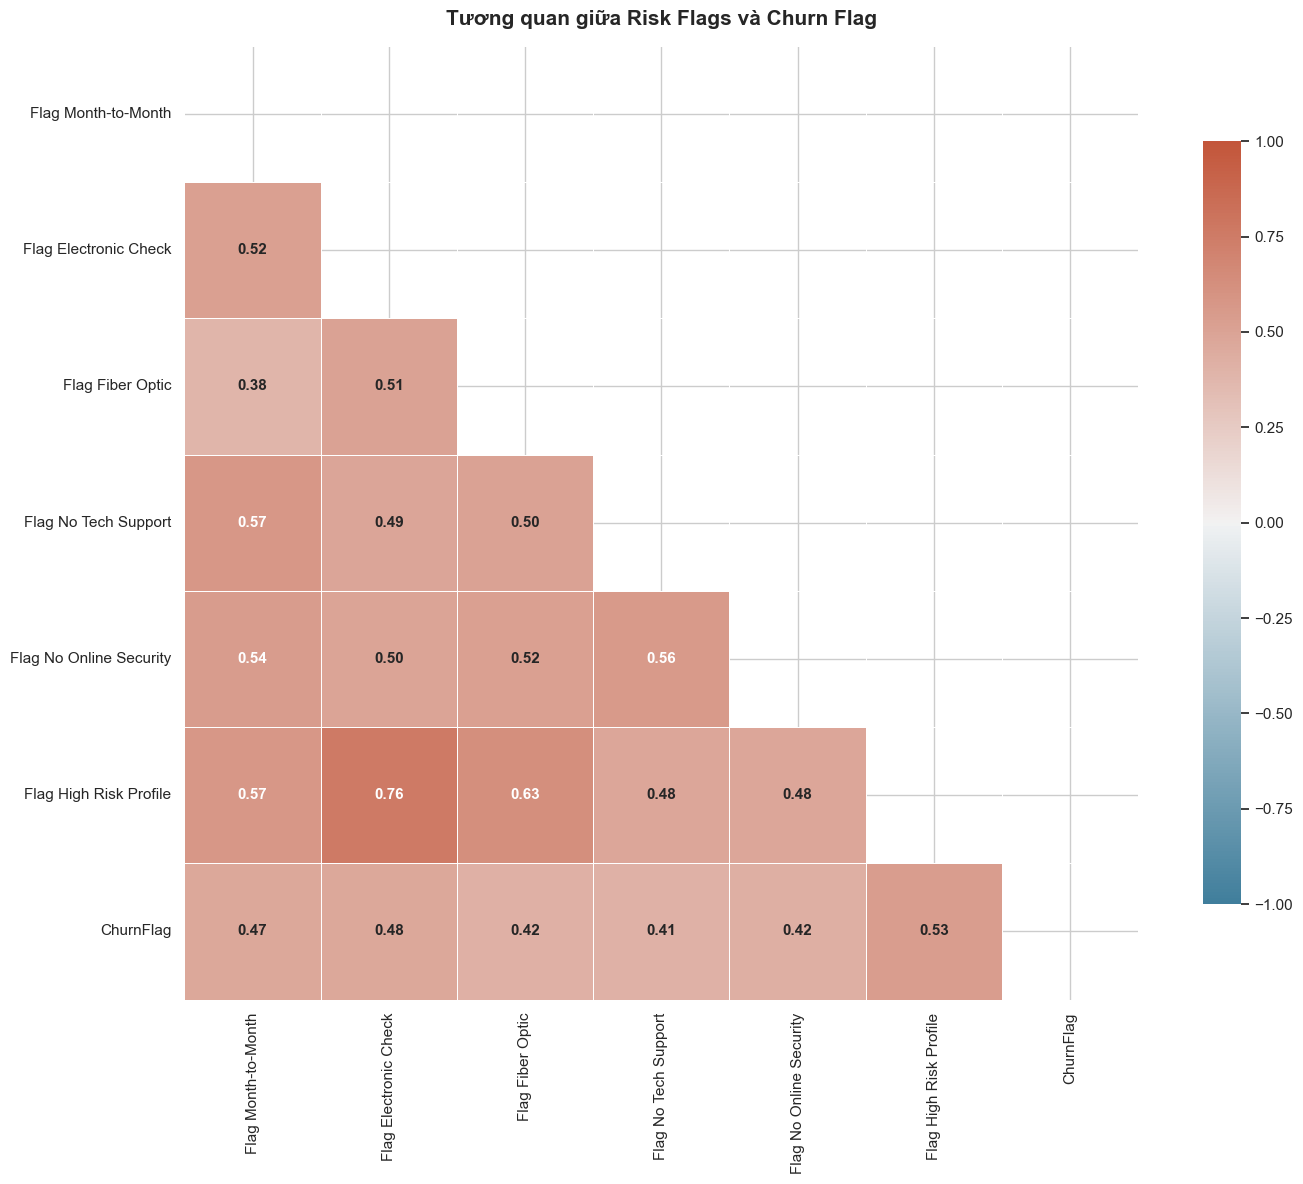

In [75]:
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_risk, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_risk, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt='.2f', square=True, linewidths=.5, 
    cbar_kws={"shrink": .8}, annot_kws={"size": 11, "fontweight": "bold"} 
)

plt.title("Tương quan giữa Risk Flags và Churn Flag", fontsize=15, fontweight='bold', pad=15)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Các *Risk Flags* không bị ảnh hưởng quá mức bởi hiện tượng Đa cộng tính *Multicollinearity*. Mức tương quan nội bộ cao nhất nằm ở cặp *flag_high_risk_profile* và *flag_electronic_check*, đạt mức 0.76. Tuy hệ số tương quan khá cao do cấu tạo của siêu cờ, con số này vẫn nằm dưới ngưỡng an toàn $< 0.8$. Vì vậy, ta có thể tạm thời giữ lại tất cả các *risk flags* ở giai đoạn này để thực hiện so sánh tính ưu việt so với các biến gốc thông qua hệ số tương quan với **Churn** .Cặp dịch vụ bổ trợ *flag_no_tech_support* và *flag_no_online_security* có độ tương quan vừa phải $0.56$, cho thấy khách hàng thường có xu hướng cùng lúc bỏ qua cả hai lớp bảo vệ này.
- Toàn bộ các biến mới đều có hệ số tương quan dương và ở mức rất tốt $> 0.4$ với biến mục tiêu. Điều này chứng minh các cờ này thực sự là những tác nhân cốt lõi khiến khách hàng rời đi.
- *flag_high_risk_profile* chứng minh được tính ưu việt của Feature Engineering khi dẫn đầu về sự tương quan với biến mục tiêu, đạt $0.53$. Siêu cờ đã tổng hợp thành công các rủi ro rời rạc thành một tín hiệu cảnh báo cực mạnh.

**Tổng hợp và Hoàn thành danh sách Đặc trưng Final Feature Selection**

**Note:** Sau quá trình cô lập và đánh giá dữ liệu thông qua $4$ bộ lọc thống kê chuyên biệt, bước cuối cùng tập trung vào việc chọn lọc những đặc trưng có độ tương quan mạnh nhất với biến mục tiêu. Việc sử dụng giá trị tuyệt đối của các hệ số tương quan ($|r|$, $|\rho|$, $V$) giúp san bằng sự khác biệt về chiều hướng và thang đo, tạo cơ sở cho việc so sánh trực diện. Việc lựa chọn đặc trưng cho mô hình **Machine Learning** tuân thủ $3$ nguyên tắc cốt lõi:
- Loại bỏ nhiễu hệ thống: Đặt ngưỡng rủi ro tại mốc $0.1$. Các đặc trưng gốc có hệ số tương quan nằm dưới ngưỡng này sẽ bị loại bỏ vì không mang lại tín hiệu dự đoán hữu ích.
- Triệt tiêu đa cộng tuyến: Loại bỏ các đặc trưng có sự trùng lặp thông tin toán học quá lớn dựa trên kết quả rà soát tuyến tính.
- Bảo tồn đặc trưng kiến tạo: Ưu tiên giữ lại các *Cờ rủi ro* và *Biến phân khúc* đã được thực chứng là có sức mạnh dự đoán vượt trội hơn hẳn so với dữ liệu thô ban đầu.

In [76]:
df1 = (
    corr_quant[['ChurnFlag']]
    .drop(index='ChurnFlag')
    .drop(index='Tenure')
    .reset_index()
    .rename(columns={'index': 'Feature', 'ChurnFlag': 'Score'})
)
df1['Method'] = "Đặc trưng Định lượng gốc"

df2 = df_cramer.rename(columns={"Đặc trưng": "Feature", "Hệ số Cramér's V": "Score"}).copy()
df2['Method'] = "Đặc trưng Định tính gốc"

replaced_vars = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']
df2 = df2[~df2['Feature'].isin(replaced_vars)]

df3 = df_spearman.rename(columns={"Đặc trưng": "Feature", "Hệ số Spearman": "Score"}).copy()
df3['Method'] = "Đặc trưng Thứ bậc"

df4= corr_risk.reset_index().rename(columns={"index": "Feature", "ChurnFlag": "Score"}).copy()
df4['Method'] = "Cờ rủi ro"

master_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

**Note:** Thực hiện *Drop* **Tenure** và **ChurnFlag** trong *DataFrame* chứa hệ số tương quan của **ChurnFlag** chắc chắn bằng $1$ và **Tenure** vì đã tạo biến xếp hạng **loyalty_tier** dựa hoàn toàn trên nó.

**Note:** Thực hiện gọi lại tất cả các đặc trưng, bao gồm *Đặc trưng định lượng gốc*, *Đặc trưng định tính gốc không cấu tạo nên Cờ rủi ro*, *Cờ rủi ro* và các *Đặc trưng thứ bậc*. Do đã chứng minh được tính ưu việt của các *Cờ rủi ro* bằng việc trực quan hóa *Xếp hạng Liên kết Biến định tính gốc so với Churn (Cramér's V)* nên để tránh trùng lặp, ta không thêm các biến định tính cấu tạo nên chúng vào biểu đồ trực quan hóa này.

**Trực quan hóa tác động của các đặc trưng lên biến mục tiêu Churn**

**Note:** Sau khi lược bỏ nhóm biến định tính nguyên bản, được đại diện hoàn toàn bởi các Cờ rủi ro, biểu đồ này là trực quan hóa cuối cùng, tập hợp những đặc trưng vượt trội nhất từ quá trình *Feature Engineering* và dữ liệu định lượng gốc. Các đặc trưng được phân loại thành 3 nhóm và đối chiếu trực tiếp với *Ngưỡng rủi ro 0.1* — ngưỡng quyết định đặc trưng được chọn cho giai đoạn huấn luyện mô hình *Machine Learning*.

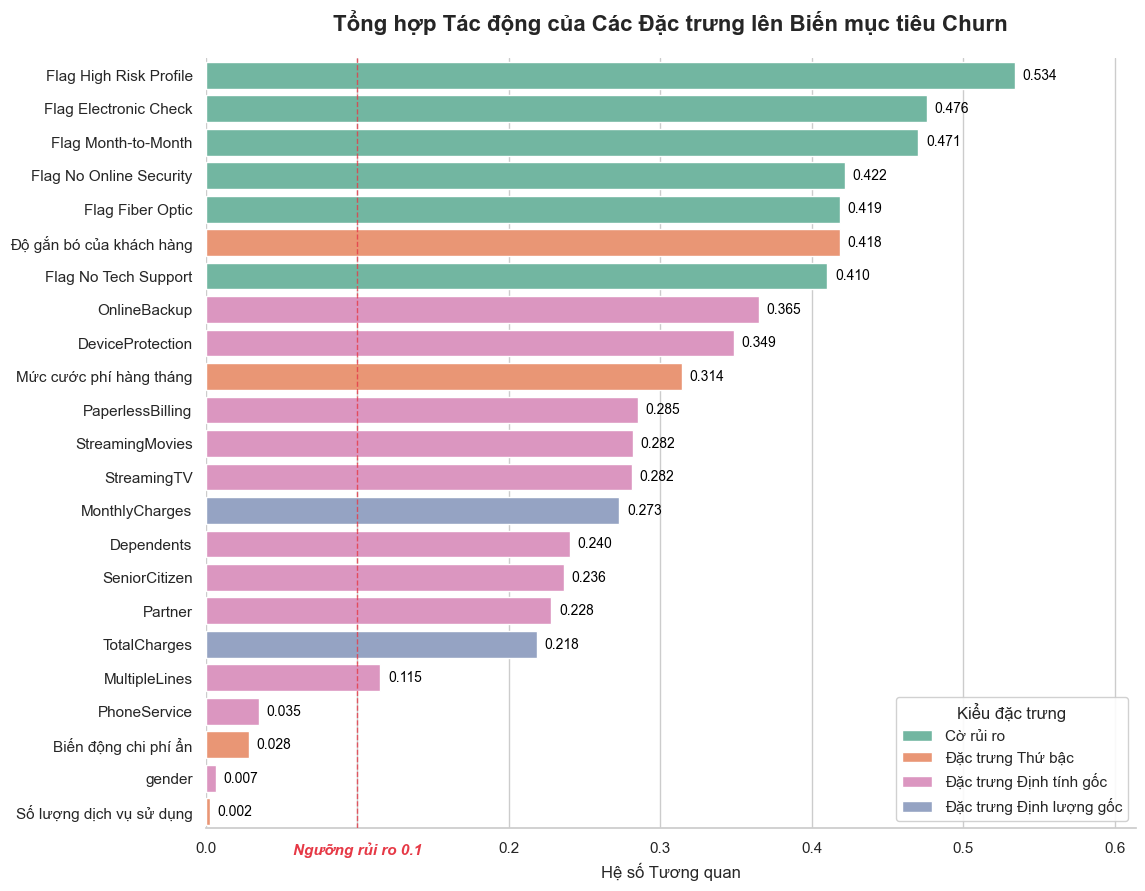

In [77]:
master_df['Absolute_Power'] = master_df['Score'].abs()
master_df = master_df[master_df['Feature'] != 'ChurnFlag']
master_df = master_df.sort_values(by='Absolute_Power', ascending=False)

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

bars = sns.barplot(data=master_df, y='Feature', x='Absolute_Power', 
                   hue='Method', dodge=False, 
                   palette = {
                    'Đặc trưng Định lượng gốc': '#8DA0CB',
                    'Đặc trưng Định tính gốc': '#E78AC3',
                    'Đặc trưng Thứ bậc': '#FC8D62',
                    'Cờ rủi ro': '#66C2A5'})

plt.title("Tổng hợp Tác động của Các Đặc trưng lên Biến mục tiêu Churn", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hệ số Tương quan", fontsize=12)
plt.ylabel("")

for p in plt.gca().patches:
    val = p.get_width()
    if val > 0:
        plt.gca().annotate(f'{val:.3f}', 
                           (val + 0.005, p.get_y() + p.get_height() / 2.), 
                           ha='left', va='center', fontsize=10, color='black')

plt.legend(title="Kiểu đặc trưng", loc='lower right', framealpha=0.9)
plt.xlim(0, master_df['Absolute_Power'].max() + 0.08)

sns.despine(left=True)
plt.axvline(x=0.1, color='#e63946', linewidth=1.0, linestyle='--', alpha=0.8, zorder=5)

ax = plt.gca()

ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
ax.set_xticks(ticks)

tick_labels = ['0.0', 'Ngưỡng rủi ro 0.1', '0.2', '0.3', '0.4', '0.5', '0.6']
labels = ax.set_xticklabels(tick_labels)

labels[1].set_color('#e63946')
labels[1].set_fontweight('bold')
labels[1].set_fontstyle('italic')
plt.show()

**Nhận xét:**
- Nhóm *Risk Flags* chứng minh được tính ưu việt tuyệt đối khi chiếm trọn các vị trí top đầu. Trong đó, **Flag High Risk Profile** có ảnh hưởng mạnh nhất đến tỷ lệ rời bỏ với hệ số $0.534$, theo sát là các cờ liên quan đến thanh toán và loại hợp đồng.
- Dù không được sử dụng để tạo *Cờ rủi ro*, các dịch vụ như **OnlineBackup** $0.365$ hay **DeviceProtection** $0.349$ vẫn cho thấy mức độ ảnh hưởng đáng kể, qua đó cần được giữ lại để cung cấp thêm góc nhìn cho mô hình.
- Biến **Độ gắn bó của khách hàng** $0.418$ và Mức cước phí hàng tháng $0.314$ cho thấy tín hiệu dự đoán rất tốt, khẳng định việc nhóm hóa *binning* các dữ liệu liên tục là một quyết định chính xác.
- Các đặc trưng tự thiết lập như **Biến động chi phí ẩn** $0.028$, **Số lượng dịch vụ sử dụng** $0.002$ cùng với gender và PhoneService bị bỏ lại hoàn toàn phía sau *Ngưỡng rủi ro*. Điều này cho thấy giới tính, số lượng dịch vụ hay sự thay đổi chi phí phụ không tạo ra động lực thực sự cho quyết định hủy hợp đồng.

**Tổng kết:**
- Ta thực hiện xóa bỏ *Biến động chi phí ẩn* và *Số lượng dịch vụ sử dụng* vì hệ số tương quan tiệm cận 0 cho thấy sức dự báo không đáng kể, cùng với đó là các biến nhiễu như *gender*, *PhoneService*.
- Triệt tiêu Đa cộng tuyến: Xóa bỏ **TotalCharges** dù hệ số đạt $0.218$ vì về mặt toán học, đây chỉ là phép nhân của **Tenure** và **MonthlyCharges**. Việc giữ lại sẽ làm nhiễu trọng số của thuật toán.
- Ngoài ra, ta cũng thực hiện loại bỏ **customerID** vì đây là biến định danh, không có giá trị học thuật và **Churn* vì đã có *flag* tương ứng 
- Giữ lại toàn bộ các biến nằm trên *Ngưỡng 0.1*, ưu tiên *Cờ rủi ro* và *Các phân khúc thứ bậc* để đến với quá trình học máy *Machine Learning*
- Thực hiện loại bỏ tất cả đặc trưng định tính cấu tạo nên các *Cờ rủi ro* **flag_month_to_month**, **flag_electronic_check**, **flag_fiber_optic**, **flag_no_tech_support**, **flag_no_online_security**, **flag_high_risk_profile**, bao gồm các đặc trưng định tính gốc **PaymentMethod**, **Contract**, **OnlineSecurity**, **InternetService**, **TechSupport** 

In [78]:
cols_to_drop = [
    'id',
    'Churn',
    'TotalCharges',
    'gender',
    'PhoneService',
    'spending_shift',
    'total_services',
    'PaymentMethod',
    'Contract',
    'OnlineSecurity',
    'InternetService',
    'TechSupport' 
]

df_model = df_train_copy.drop(columns=cols_to_drop).copy()

In [79]:
df_model.head(20)

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineBackup,DeviceProtection,StreamingTV,StreamingMovies,PaperlessBilling,...,TotalServices,churn_flag,loyalty_tier,charge_segment,flag_month_to_month,flag_electronic_check,flag_fiber_optic,flag_no_tech_support,flag_no_online_security,flag_high_risk_profile
0,No,Yes,Yes,29,No,No,Yes,No,No,Yes,...,3,0,Familiar,Standard,0,0,0,0,0,0
1,No,Yes,Yes,58,No,Yes,No,Yes,No,No,...,4,0,Loyal,Standard,0,0,0,0,0,0
2,No,Yes,No,58,Yes,Yes,No,Yes,Yes,Yes,...,4,0,Loyal,Premium,1,1,1,1,1,1
3,No,No,No,1,No,No,No,No,No,Yes,...,0,1,Onboarding,Standard,1,1,1,1,1,1
4,No,No,No,1,No,No,No,No,No,Yes,...,0,1,Onboarding,Premium,1,1,1,1,1,1
5,No,Yes,Yes,1,No,No internet service,No internet service,No internet service,No internet service,Yes,...,0,0,Onboarding,Budget,1,0,0,0,0,0
6,No,Yes,Yes,24,No,No internet service,No internet service,No internet service,No internet service,No,...,0,0,Second Year,Budget,1,0,0,0,0,0
7,No,Yes,No,72,Yes,Yes,Yes,Yes,Yes,No,...,7,0,Loyal,Premium,0,1,0,0,0,0
8,Yes,No,No,1,Yes,No,Yes,No,No,Yes,...,2,1,Onboarding,Premium,1,1,1,1,1,1
9,No,No,No,55,No,Yes,No,Yes,Yes,Yes,...,4,0,Loyal,Premium,1,1,1,1,0,1


In [80]:

df_model.to_csv('model.csv', index=False)

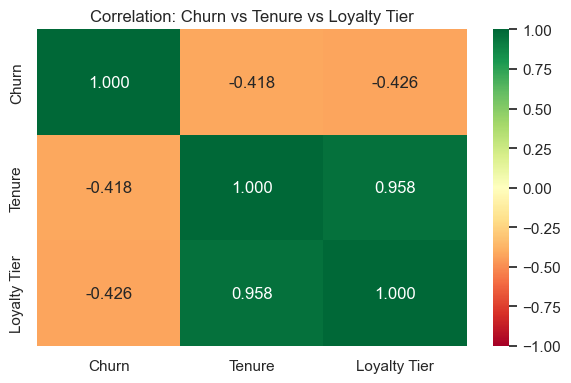

In [81]:
# Encode loyalty_tier thành số
tier_order = ['Onboarding', 'Second Year', 'Familiar', 'Loyal']
df_model['loyalty_tier_enc'] = df_model['loyalty_tier'].map({t: i for i, t in enumerate(tier_order)})

# Correlation matrix
corr = df_model[['churn_flag', 'tenure', 'loyalty_tier_enc']].corr()

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            xticklabels=['Churn', 'Tenure', 'Loyalty Tier'],
            yticklabels=['Churn', 'Tenure', 'Loyalty Tier'])
plt.title('Correlation: Churn vs Tenure vs Loyalty Tier')
plt.tight_layout()
plt.show()